In [8]:
import os
import sys
import torch
import torch.nn as nn
from torchvision import models as torchvision_models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

sys.path.append('..')

from src.config import config
from src.models import get_model
from src.dataset import HAM10000Dataset
from src.transforms import get_transforms
from src.eval import evaluate_model_performance
from efficientnet_pytorch import EfficientNet
# ตั้งค่าฟอนต์ให้ดูเป็น Paper (Times New Roman / Serif)
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 300
})

device = config.DEVICE


### Load Test Data

In [2]:
# 1. Load Test Data
test_trans = get_transforms(split='test') 
test_ds = HAM10000Dataset(config.PROCESSED_DATA_DIR / "test.csv", transform=test_trans)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=config.BATCH_SIZE, shuffle=False)

In [3]:
# 2. Define Experiments (ตาม run_ablation.py)
experiments = {
    "Exp1: Baseline (Vanilla)": {
        "type": "resnet",
        "path": config.CHECKPOINT_DIR / "best_model_resnet50_vanilla.pth",
        "use_cbam": False
    },
    "Exp2: + CSA": {
        "type": "resnet",
        "path": config.CHECKPOINT_DIR / "exp2_best.pth",
        "use_cbam": False
    },
    "Exp3: + CSA + WFL": {
        "type": "resnet",
        "path": config.CHECKPOINT_DIR / "exp3_best.pth",
        "use_cbam": False
    },
    "Exp4: Full CAMAD": {
        "type": "resnet",
        "path": config.CHECKPOINT_DIR / "best_model_resnet50_cbam.pth",
        "use_cbam": True
    },
    "External: EfficientNet-B0": {
        "type": "efficientnet",
        "path": config.CHECKPOINT_DIR / "best_model_efficientnet_b0.pth",
        "use_cbam": False
    }
}

loaded_models = {}

print("🔄 Loading Models...")
for name, settings in experiments.items():
    try:
        model = None
        print("\n" + "="*70)
        print(f"🚀 Running Experiment: {name}")
        print(f"   ➜ Model type : {settings['type']}")
        print(f"   ➜ Checkpoint : {settings['path'].name}")
        # 1. แยกโหลดตาม Architecture
        if settings['type'] == 'resnet':
            config.BASE_MODEL = 'resnet50'
            config.USE_CBAM = settings['use_cbam']
            model = get_model().to(device)
            # Load Weights Normally
            checkpoint = torch.load(settings['path'], map_location=device)
            state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
            model.load_state_dict(state_dict, strict=False)

        
        elif settings['type'] == 'efficientnet':
            # ต้องแก้ Layer สุดท้ายให้ตรงกับ 7 คลาสของ HAM10000
            model = torchvision_models.efficientnet_b0(weights=None)
            num_ftrs = model.classifier[1].in_features
            model.classifier[1] = nn.Linear(num_ftrs, 7)
            model = model.to(device)

            # Load Weights & Fix Keys
            checkpoint = torch.load(settings['path'], map_location=device)
            state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
            
            new_state_dict = {}
            for k, v in state_dict.items():
                # ลบ prefix 'backbone.' ออก ถ้ามี
                new_k = k.replace('backbone.', '') 
                new_state_dict[new_k] = v
                
            # Load with strict=True เพื่อความชัวร์ (ถ้า key ตรงแล้ว)
            # แต่ใส่ False ไว้ก่อนกันพลาดเรื่อง key ยิบย่อย
            model.load_state_dict(new_state_dict, strict=False)
        
        # Success Check
        if model is not None:
            model.eval()
            loaded_models[name] = model
            print(f"✅ Loaded: {name}")
            
    except Exception as e:
        print(f"⚠️ Error loading {name}: {e}")

🔄 Loading Models...

🚀 Running Experiment: Exp1: Baseline (Vanilla)
   ➜ Model type : resnet
   ➜ Checkpoint : best_model_resnet50_vanilla.pth
 Building Model: ResNet50 | CBAM=False
✅ Loaded: Exp1: Baseline (Vanilla)

🚀 Running Experiment: Exp2: + CSA
   ➜ Model type : resnet
   ➜ Checkpoint : exp2_best.pth
 Building Model: ResNet50 | CBAM=False
✅ Loaded: Exp2: + CSA

🚀 Running Experiment: Exp3: + CSA + WFL
   ➜ Model type : resnet
   ➜ Checkpoint : exp3_best.pth
 Building Model: ResNet50 | CBAM=False
✅ Loaded: Exp3: + CSA + WFL

🚀 Running Experiment: Exp4: Full CAMAD
   ➜ Model type : resnet
   ➜ Checkpoint : best_model_resnet50_cbam.pth
 Building Model: ResNet50 | CBAM=True
✅ Loaded: Exp4: Full CAMAD

🚀 Running Experiment: External: EfficientNet-B0
   ➜ Model type : efficientnet
   ➜ Checkpoint : best_model_efficientnet_b0.pth
✅ Loaded: External: EfficientNet-B0


### PLOTTING ROC & PR CURVES

💾 Extracting raw curve data...
Evaluating Model...

Classification Report
              precision    recall  f1-score   support

       akiec     0.3495    0.7059    0.4675        51
         bcc     0.5833    0.6364    0.6087        77
         bkl     0.6667    0.2803    0.3946       157
          df     0.2642    0.6364    0.3733        22
         mel     0.5119    0.2560    0.3413       168
          nv     0.8437    0.9120    0.8765      1000
        vasc     0.7308    0.8636    0.7917        22

    accuracy                         0.7462      1497
   macro avg     0.5643    0.6129    0.5505      1497
weighted avg     0.7475    0.7462    0.7295      1497

Balanced Accuracy: 0.6129
Melanoma Recall:   0.2560

 Saved Confusion Matrix to /Users/mati/adv_skin_cancer/reports/figures/confusion_matrix_final.png


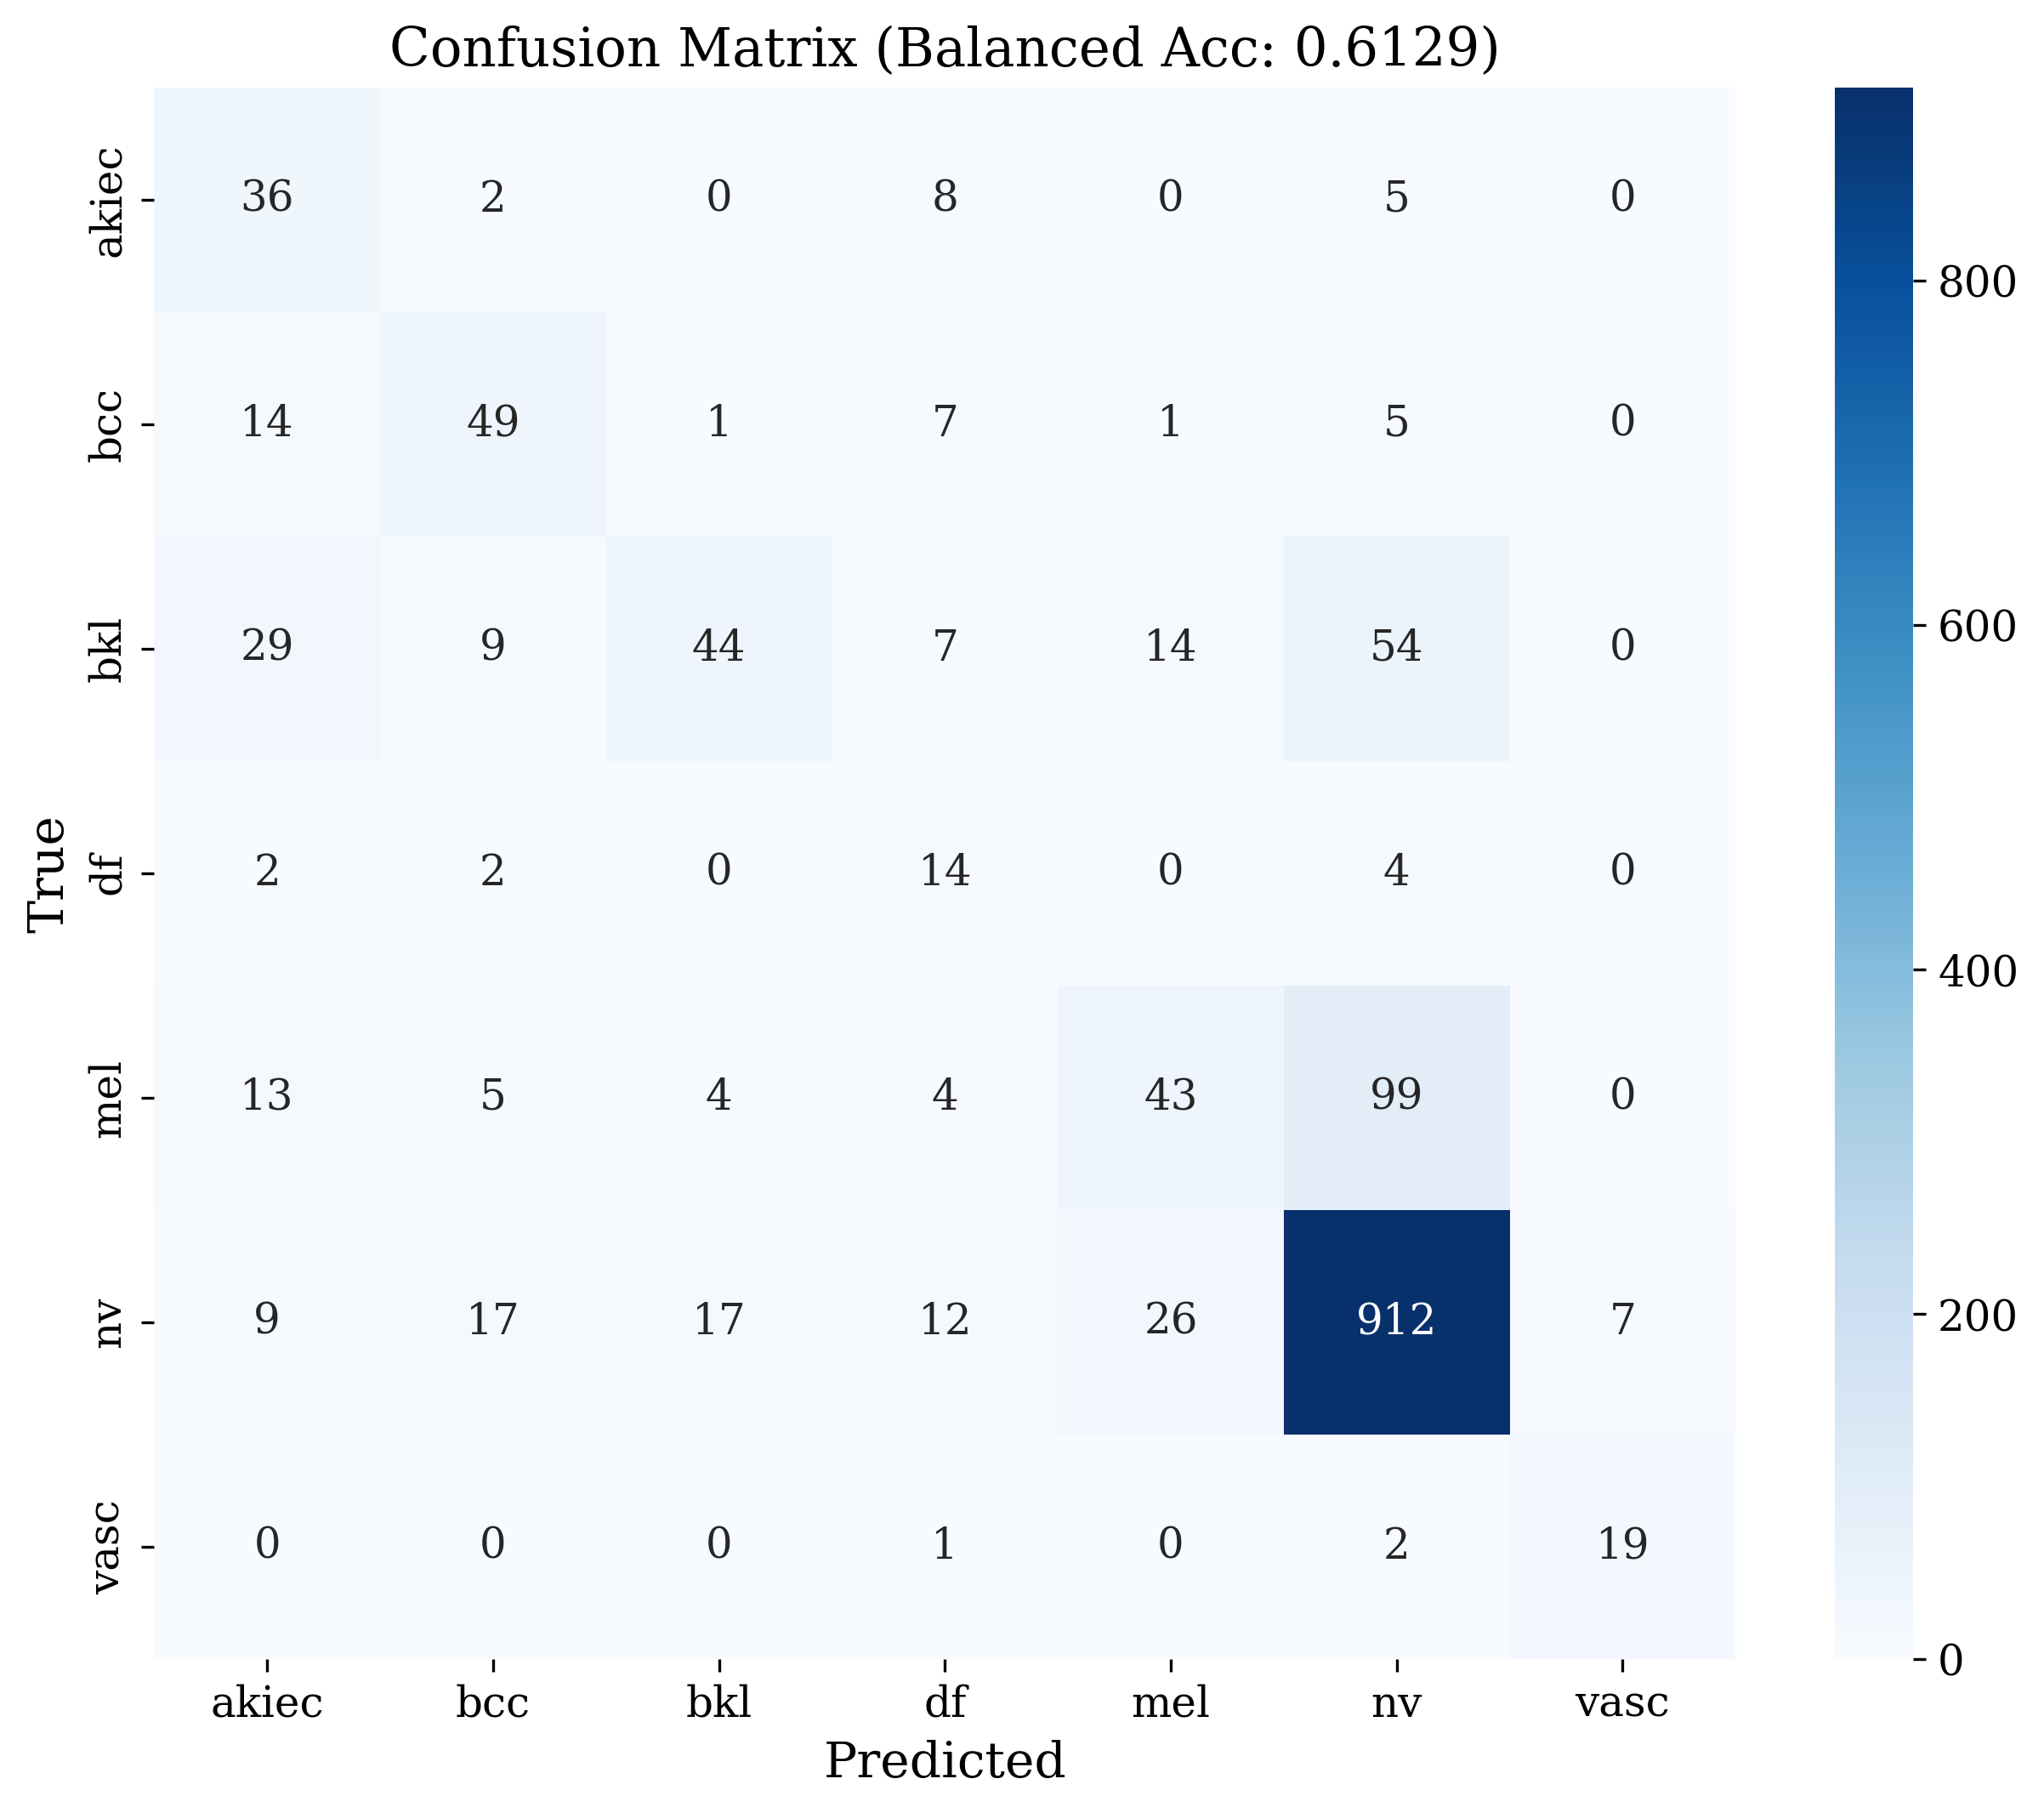

Evaluating Model...

Classification Report
              precision    recall  f1-score   support

       akiec     0.5694    0.8039    0.6667        51
         bcc     0.7465    0.6883    0.7162        77
         bkl     0.7600    0.4841    0.5914       157
          df     0.6667    0.5455    0.6000        22
         mel     0.7157    0.4345    0.5407       168
          nv     0.8575    0.9570    0.9045      1000
        vasc     0.7778    0.6364    0.7000        22

    accuracy                         0.8190      1497
   macro avg     0.7277    0.6500    0.6742      1497
weighted avg     0.8119    0.8190    0.8056      1497

Balanced Accuracy: 0.6500
Melanoma Recall:   0.4345

 Saved Confusion Matrix to /Users/mati/adv_skin_cancer/reports/figures/confusion_matrix_final.png


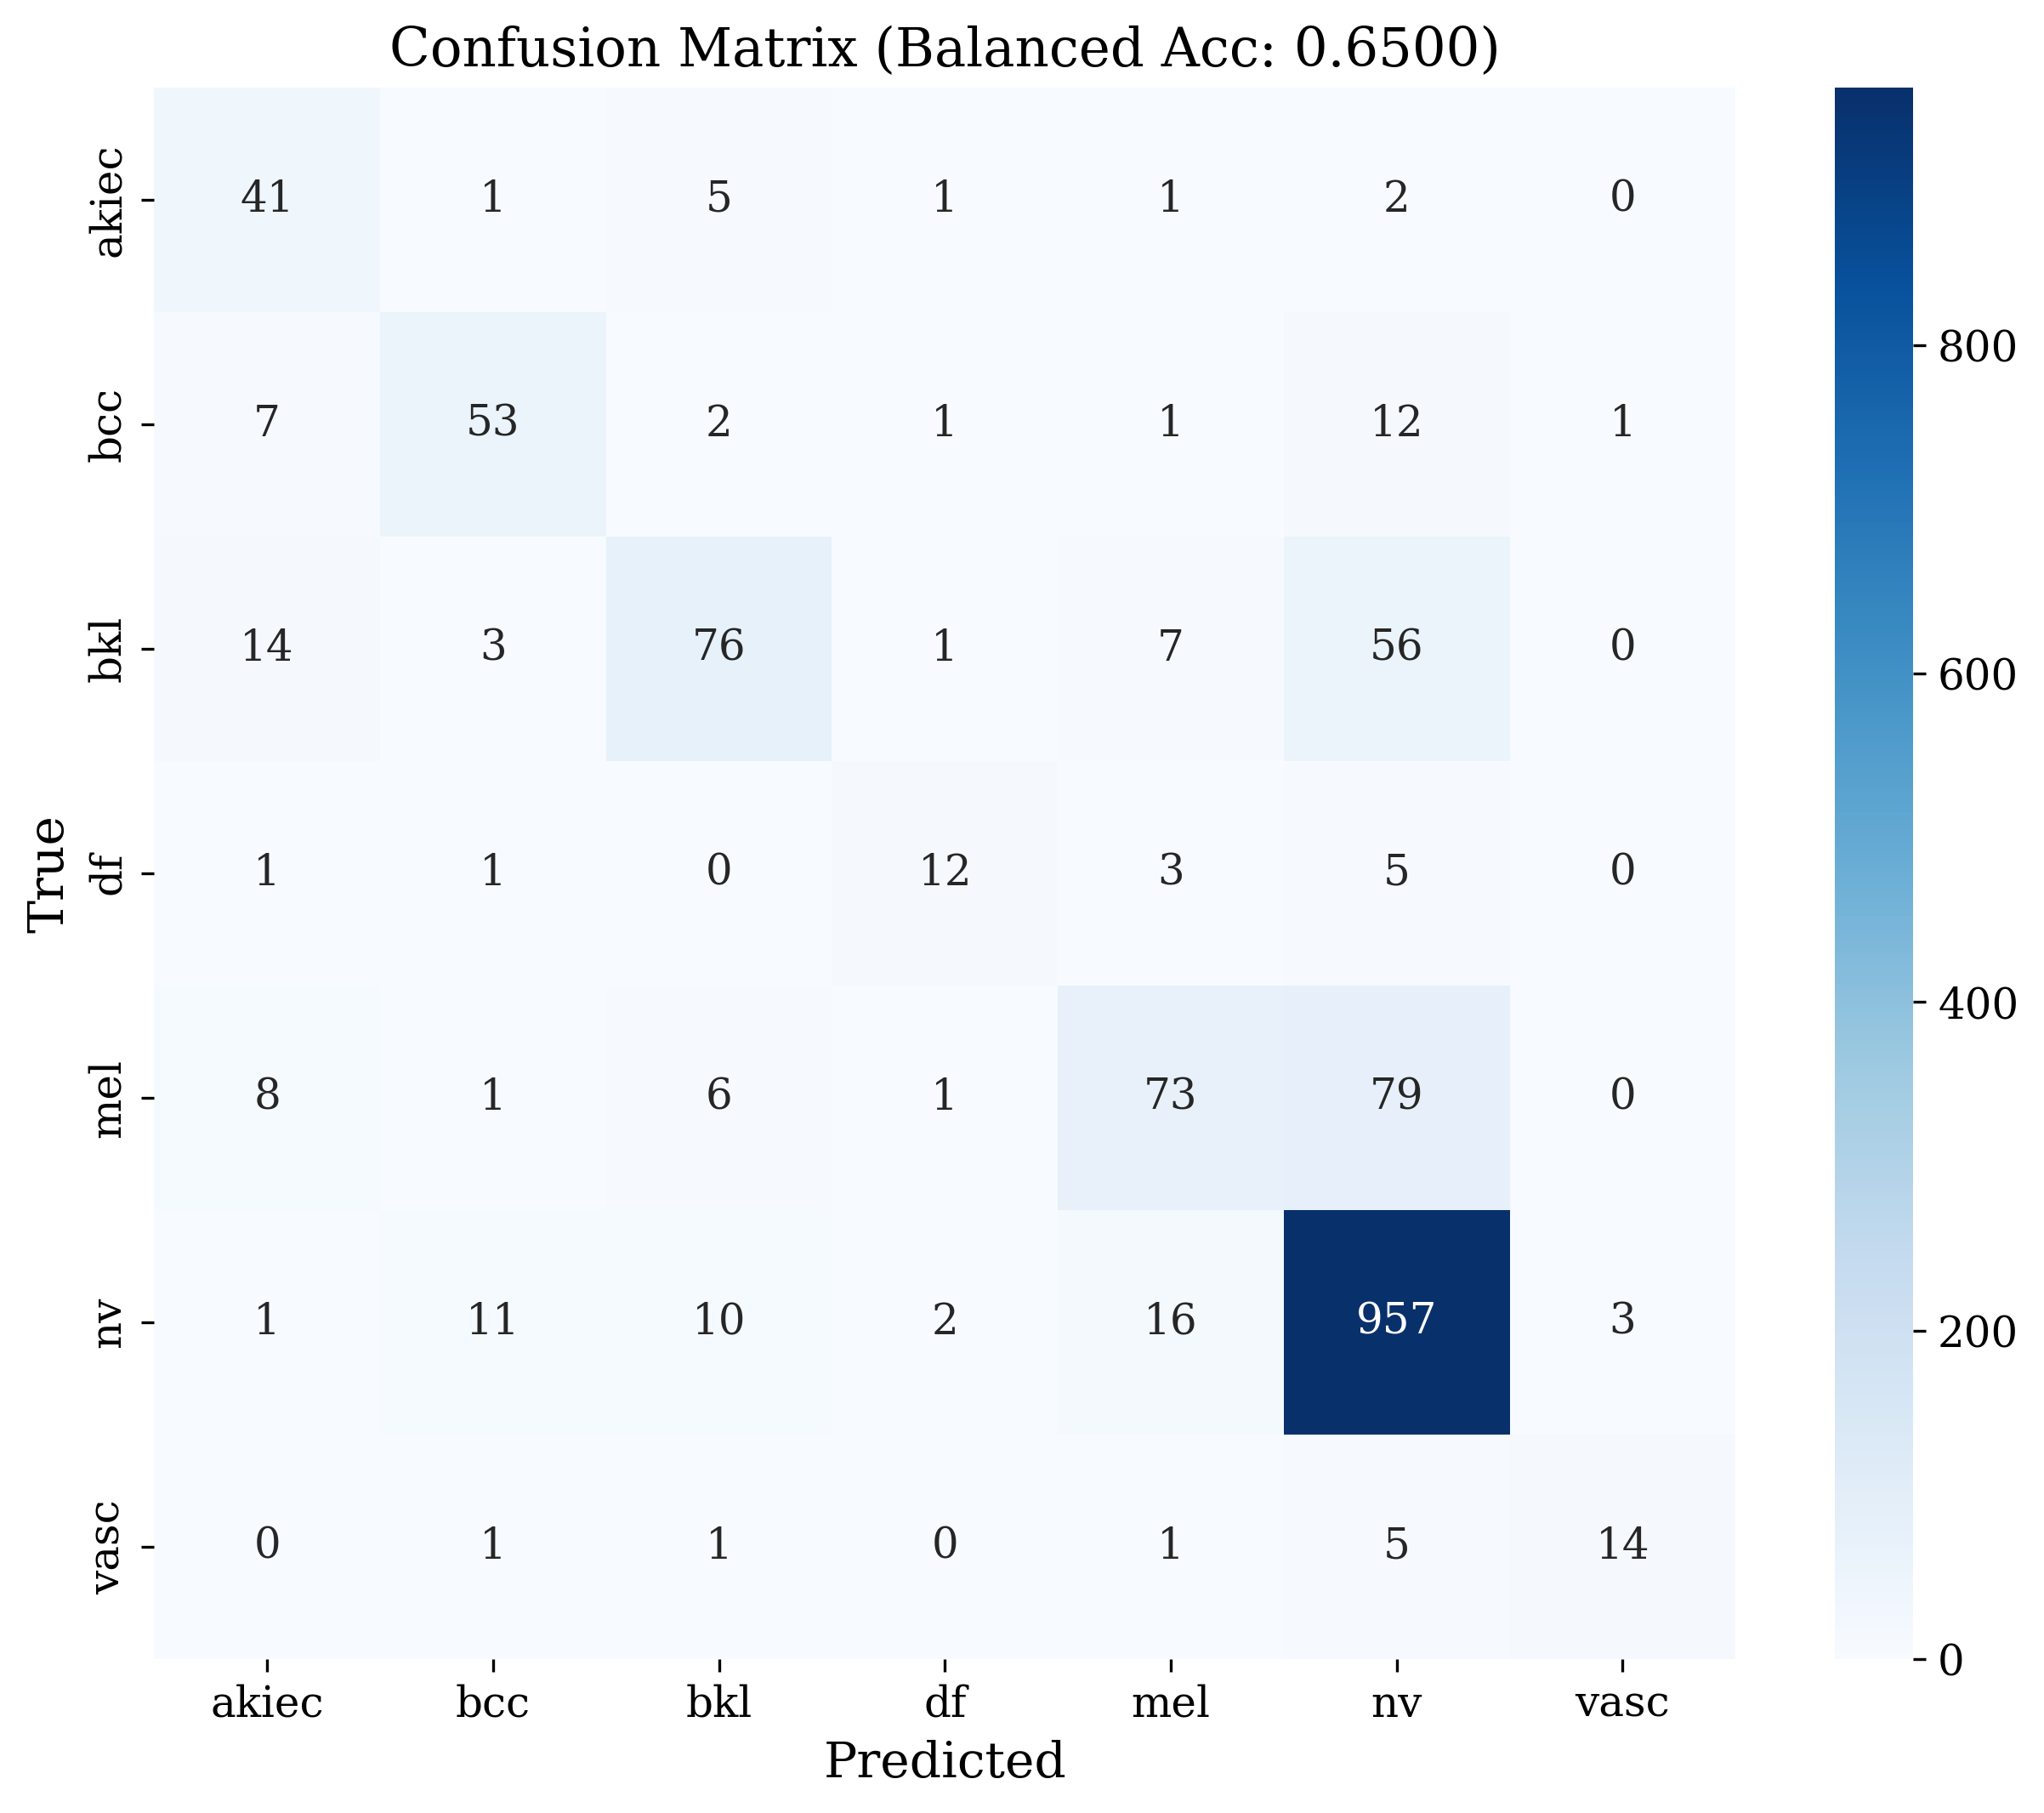

Evaluating Model...

Classification Report
              precision    recall  f1-score   support

       akiec     0.4200    0.8235    0.5563        51
         bcc     0.6494    0.6494    0.6494        77
         bkl     0.7700    0.4904    0.5992       157
          df     0.5714    0.7273    0.6400        22
         mel     0.6562    0.6250    0.6402       168
          nv     0.9050    0.9150    0.9100      1000
        vasc     0.9048    0.8636    0.8837        22

    accuracy                         0.8176      1497
   macro avg     0.6967    0.7277    0.6970      1497
weighted avg     0.8284    0.8176    0.8173      1497

Balanced Accuracy: 0.7277
Melanoma Recall:   0.6250

 Saved Confusion Matrix to /Users/mati/adv_skin_cancer/reports/figures/confusion_matrix_final.png


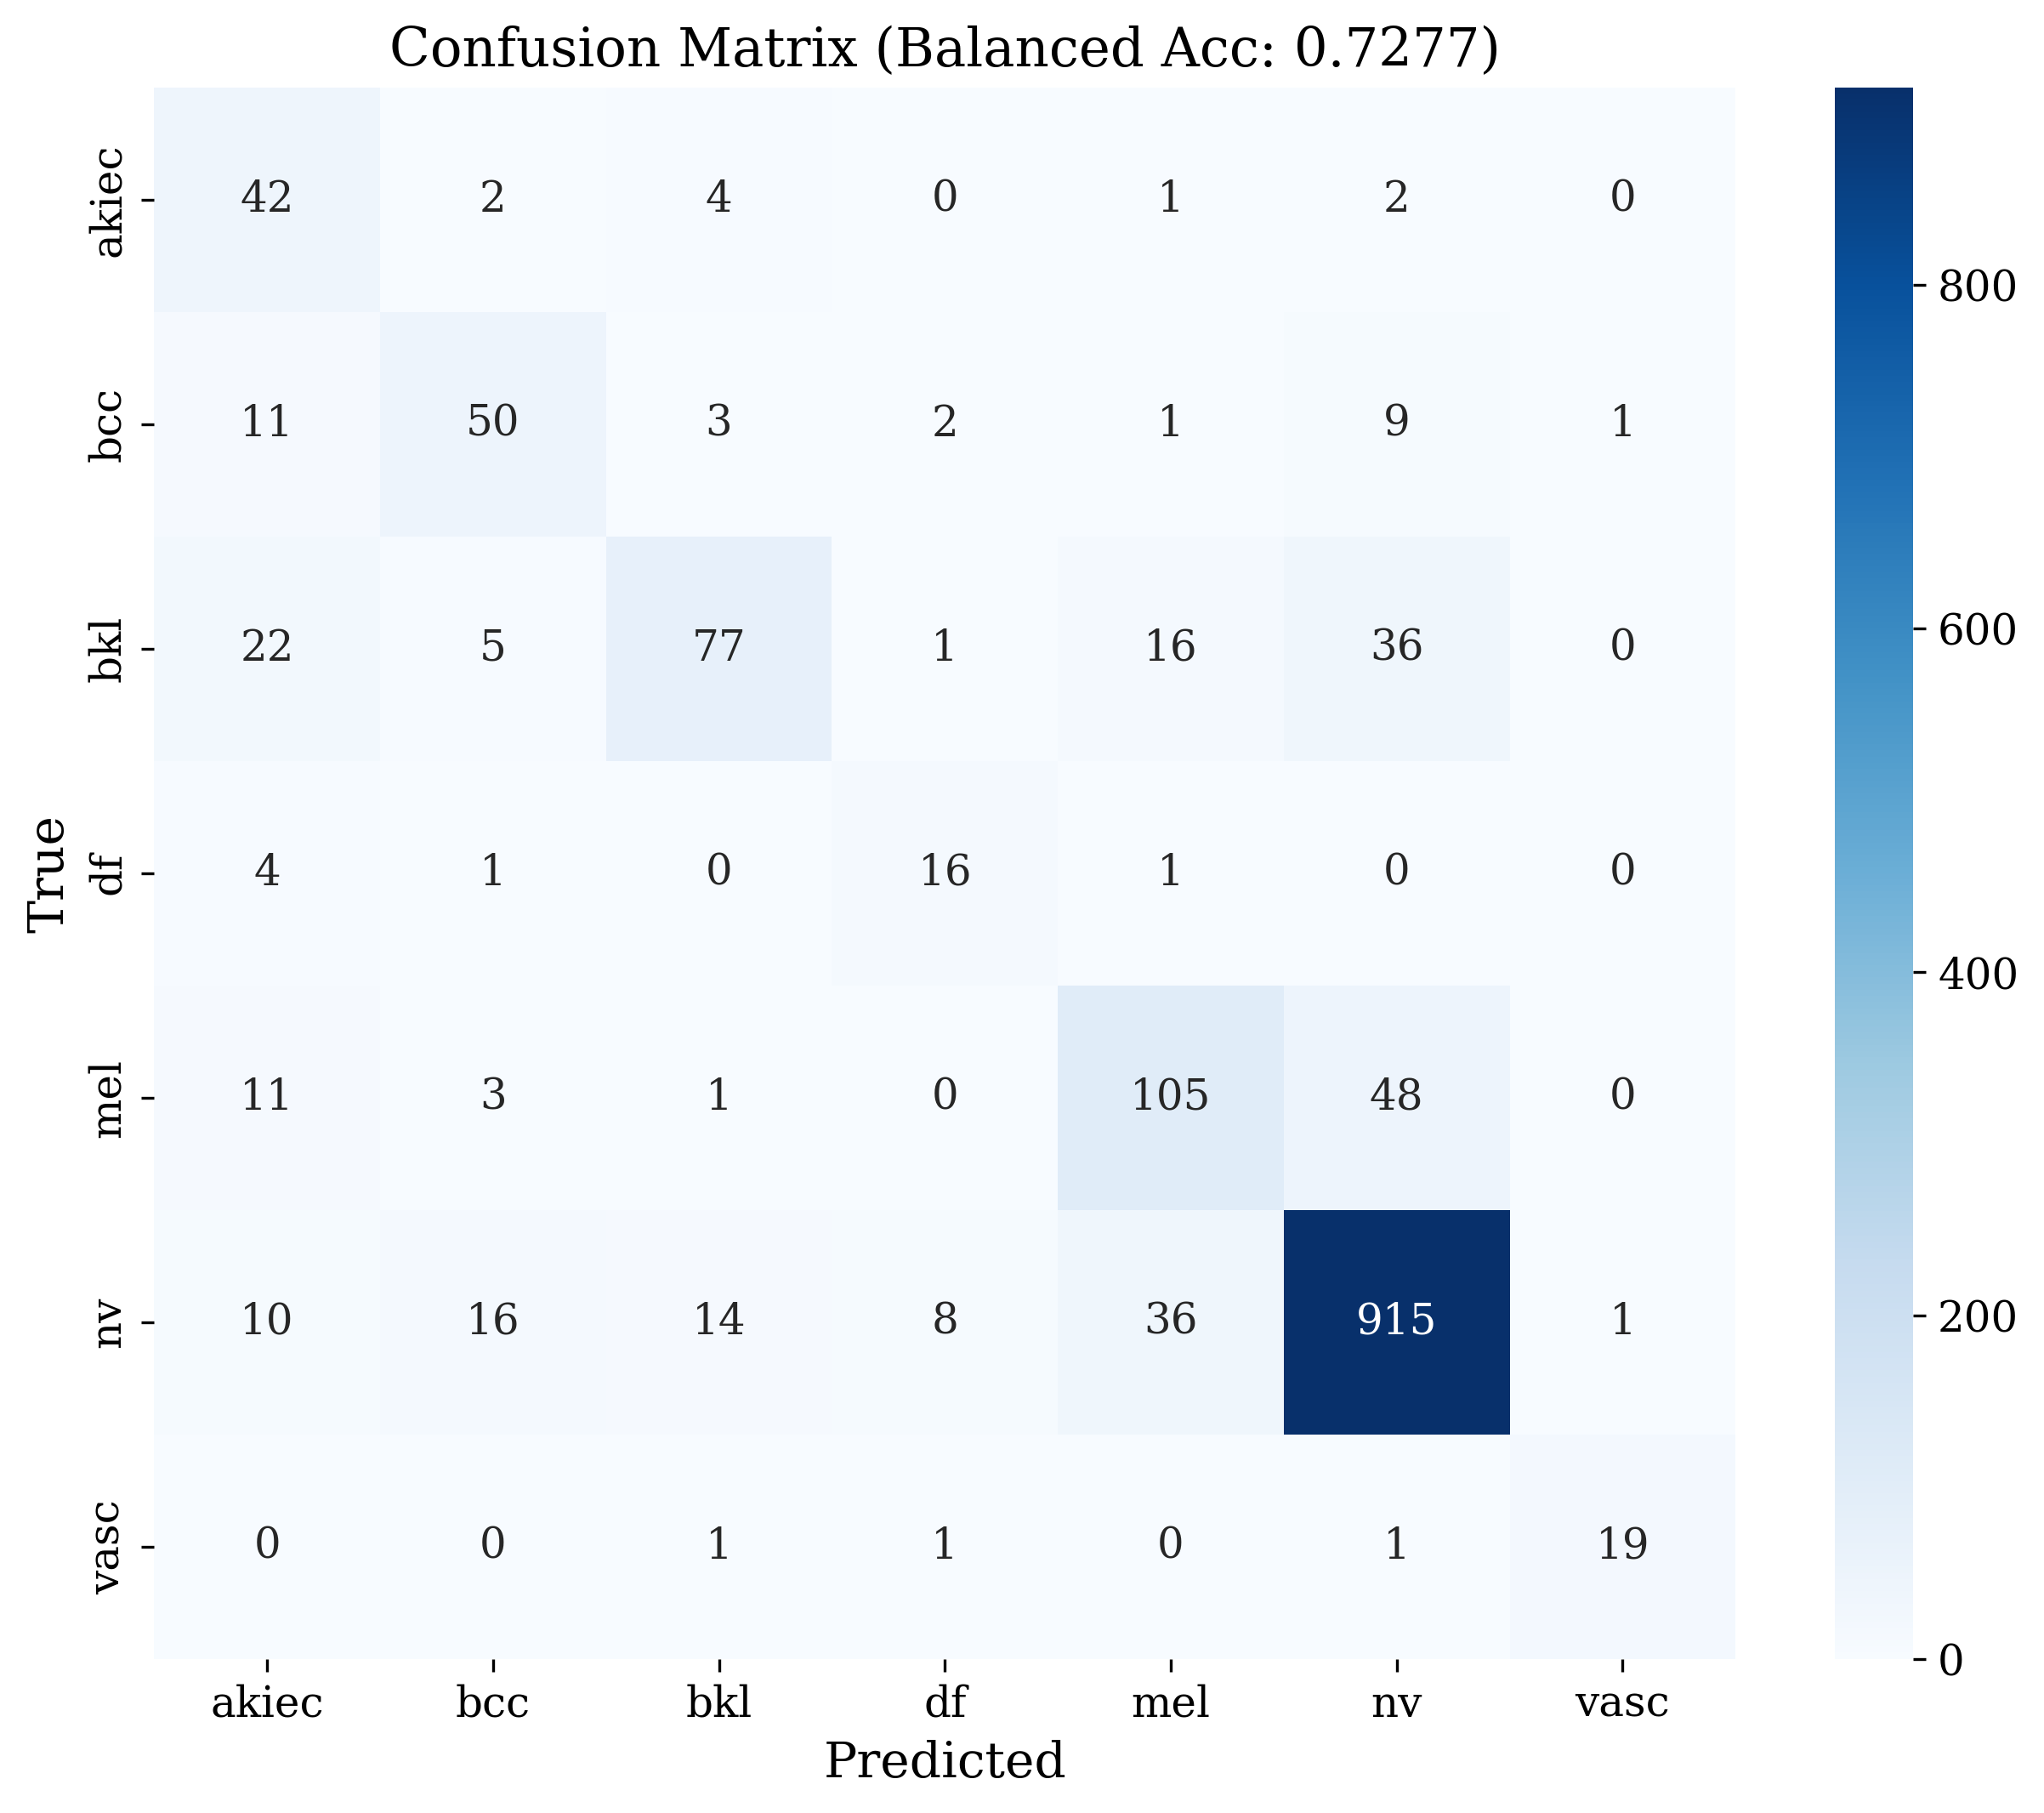

Evaluating Model...

Classification Report
              precision    recall  f1-score   support

       akiec     0.5821    0.7647    0.6610        51
         bcc     0.7568    0.7273    0.7417        77
         bkl     0.6712    0.6242    0.6469       157
          df     0.8333    0.4545    0.5882        22
         mel     0.6575    0.5714    0.6115       168
          nv     0.8944    0.9230    0.9085      1000
        vasc     0.9000    0.8182    0.8571        22

    accuracy                         0.8283      1497
   macro avg     0.7565    0.6976    0.7164      1497
weighted avg     0.8259    0.8283    0.8252      1497

Balanced Accuracy: 0.6976
Melanoma Recall:   0.5714

 Saved Confusion Matrix to /Users/mati/adv_skin_cancer/reports/figures/confusion_matrix_final.png


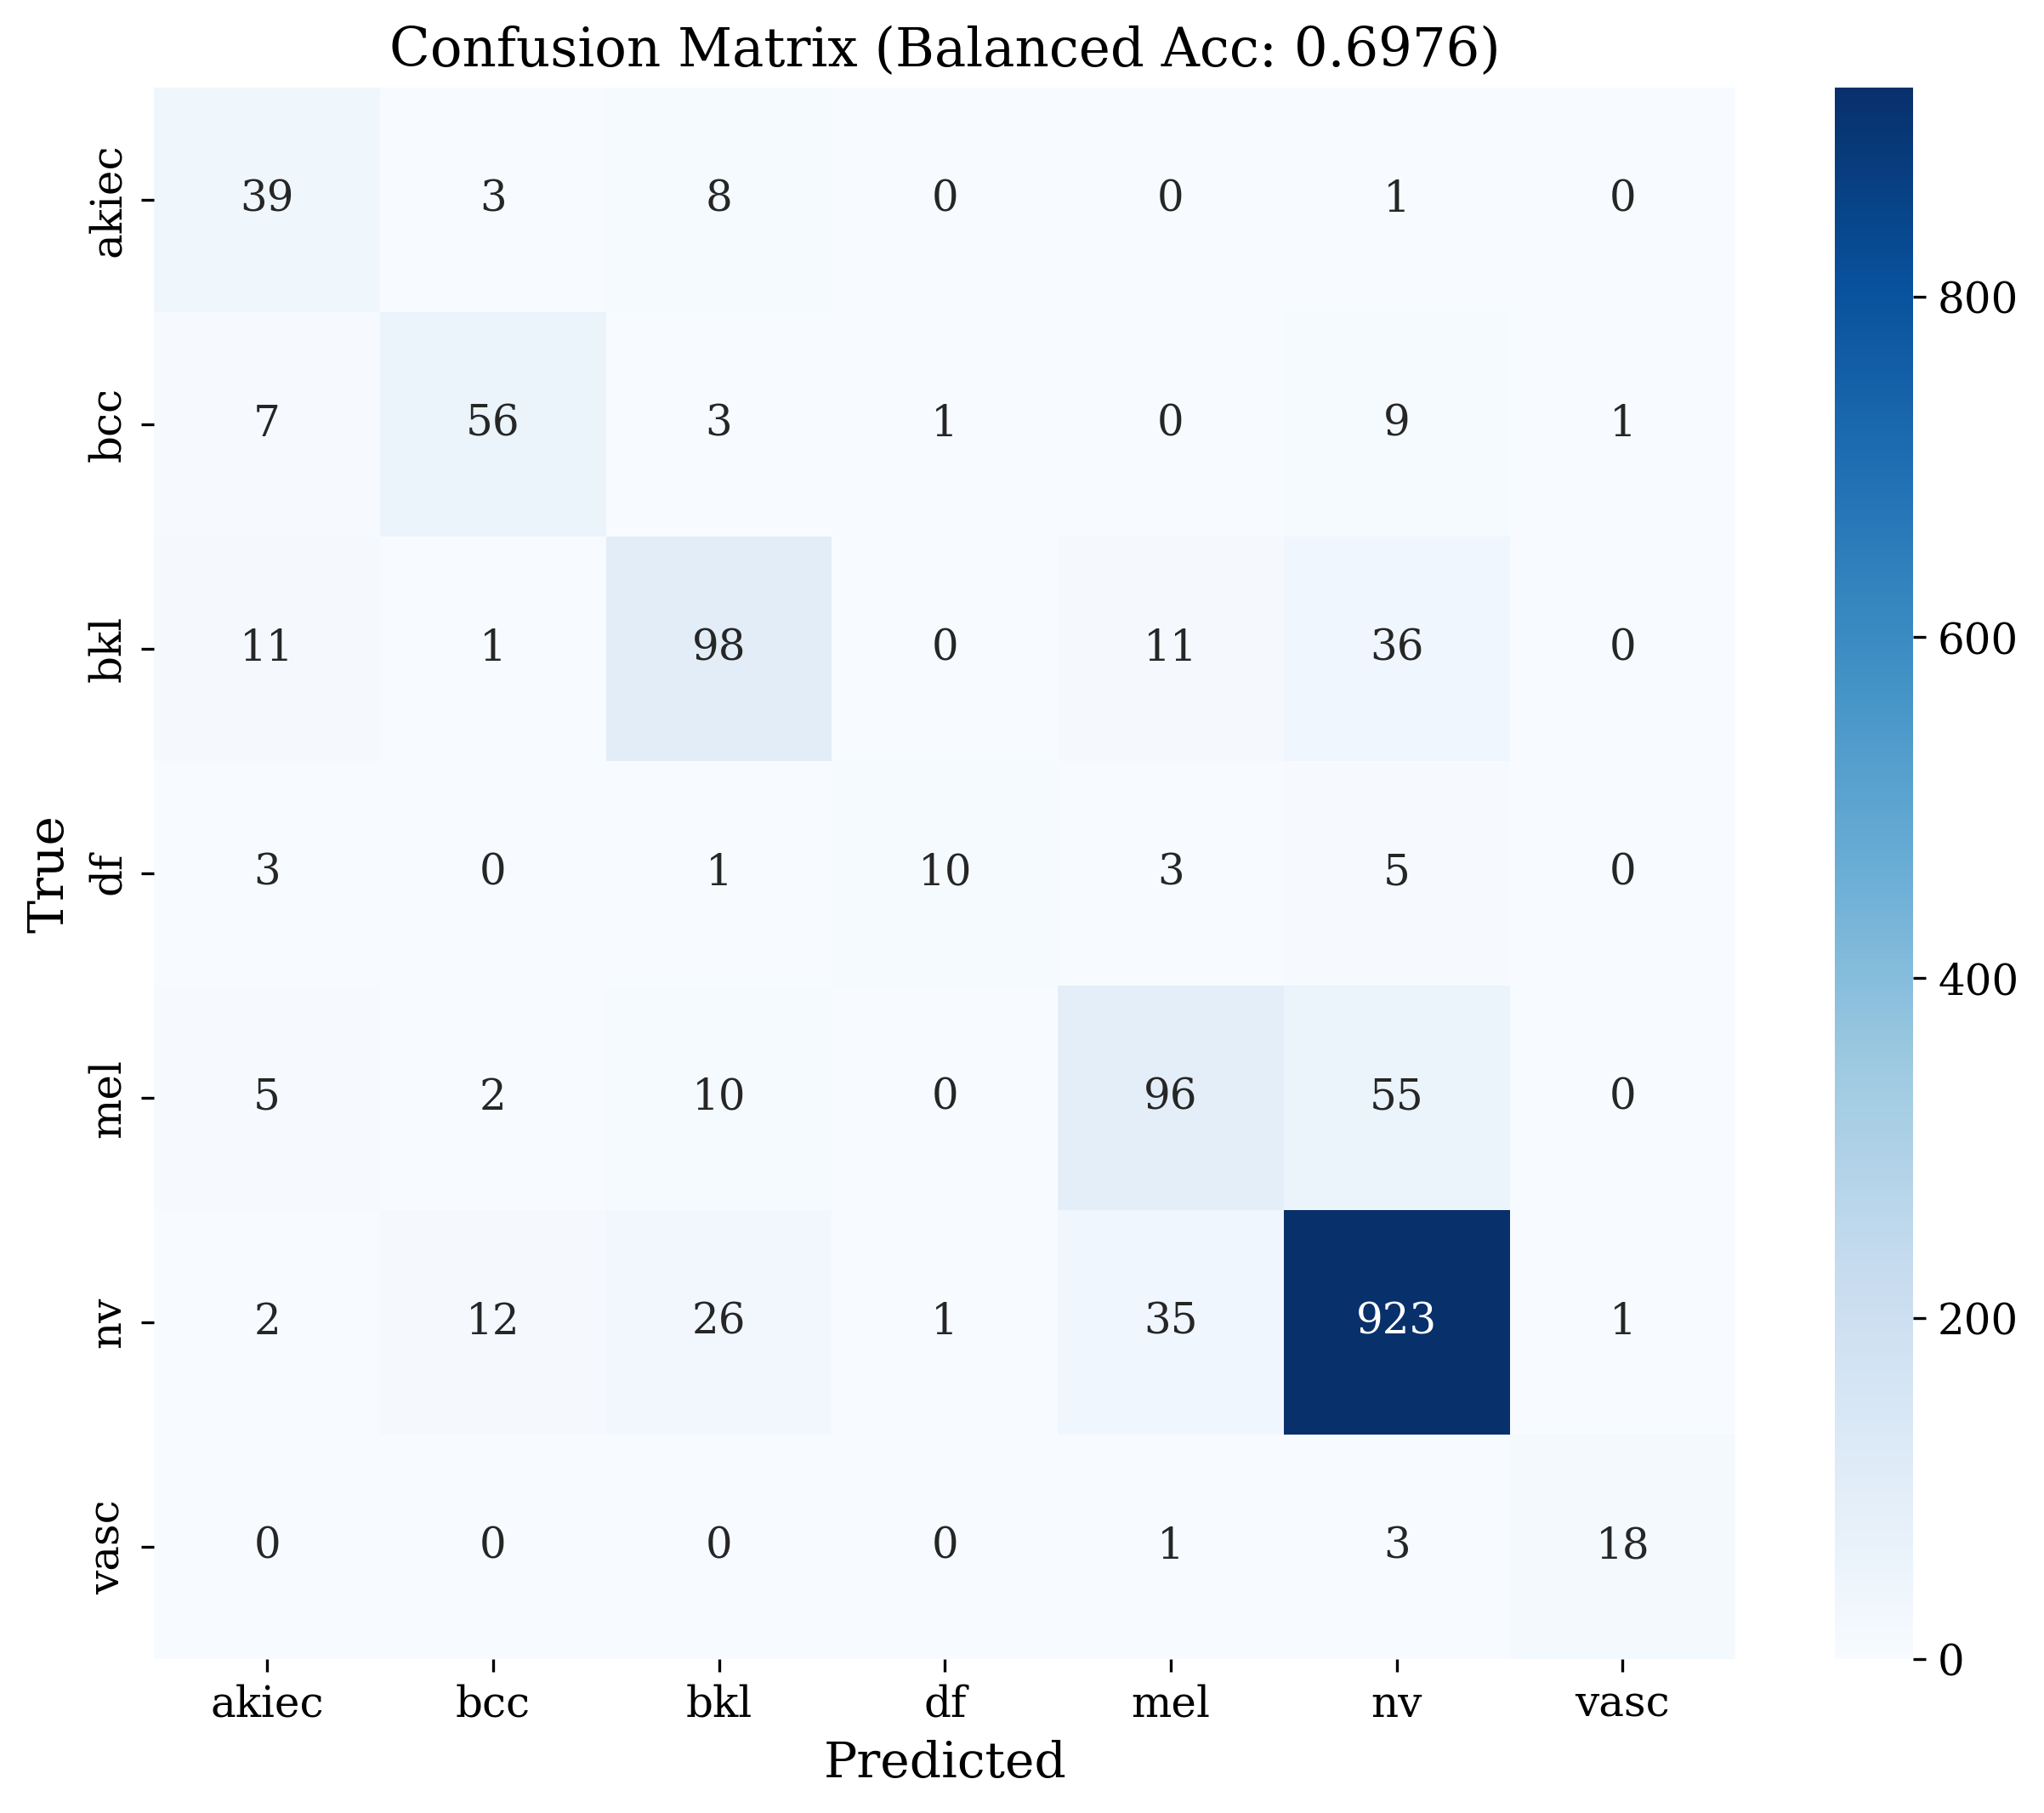

Evaluating Model...

Classification Report
              precision    recall  f1-score   support

       akiec     0.5970    0.7843    0.6780        51
         bcc     0.6667    0.8052    0.7294        77
         bkl     0.6444    0.5541    0.5959       157
          df     1.0000    0.1364    0.2400        22
         mel     0.6023    0.6131    0.6077       168
          nv     0.9143    0.9180    0.9162      1000
        vasc     0.7500    0.8182    0.7826        22

    accuracy                         0.8223      1497
   macro avg     0.7393    0.6613    0.6500      1497
weighted avg     0.8263    0.8223    0.8183      1497

Balanced Accuracy: 0.6613
Melanoma Recall:   0.6131

 Saved Confusion Matrix to /Users/mati/adv_skin_cancer/reports/figures/confusion_matrix_final.png


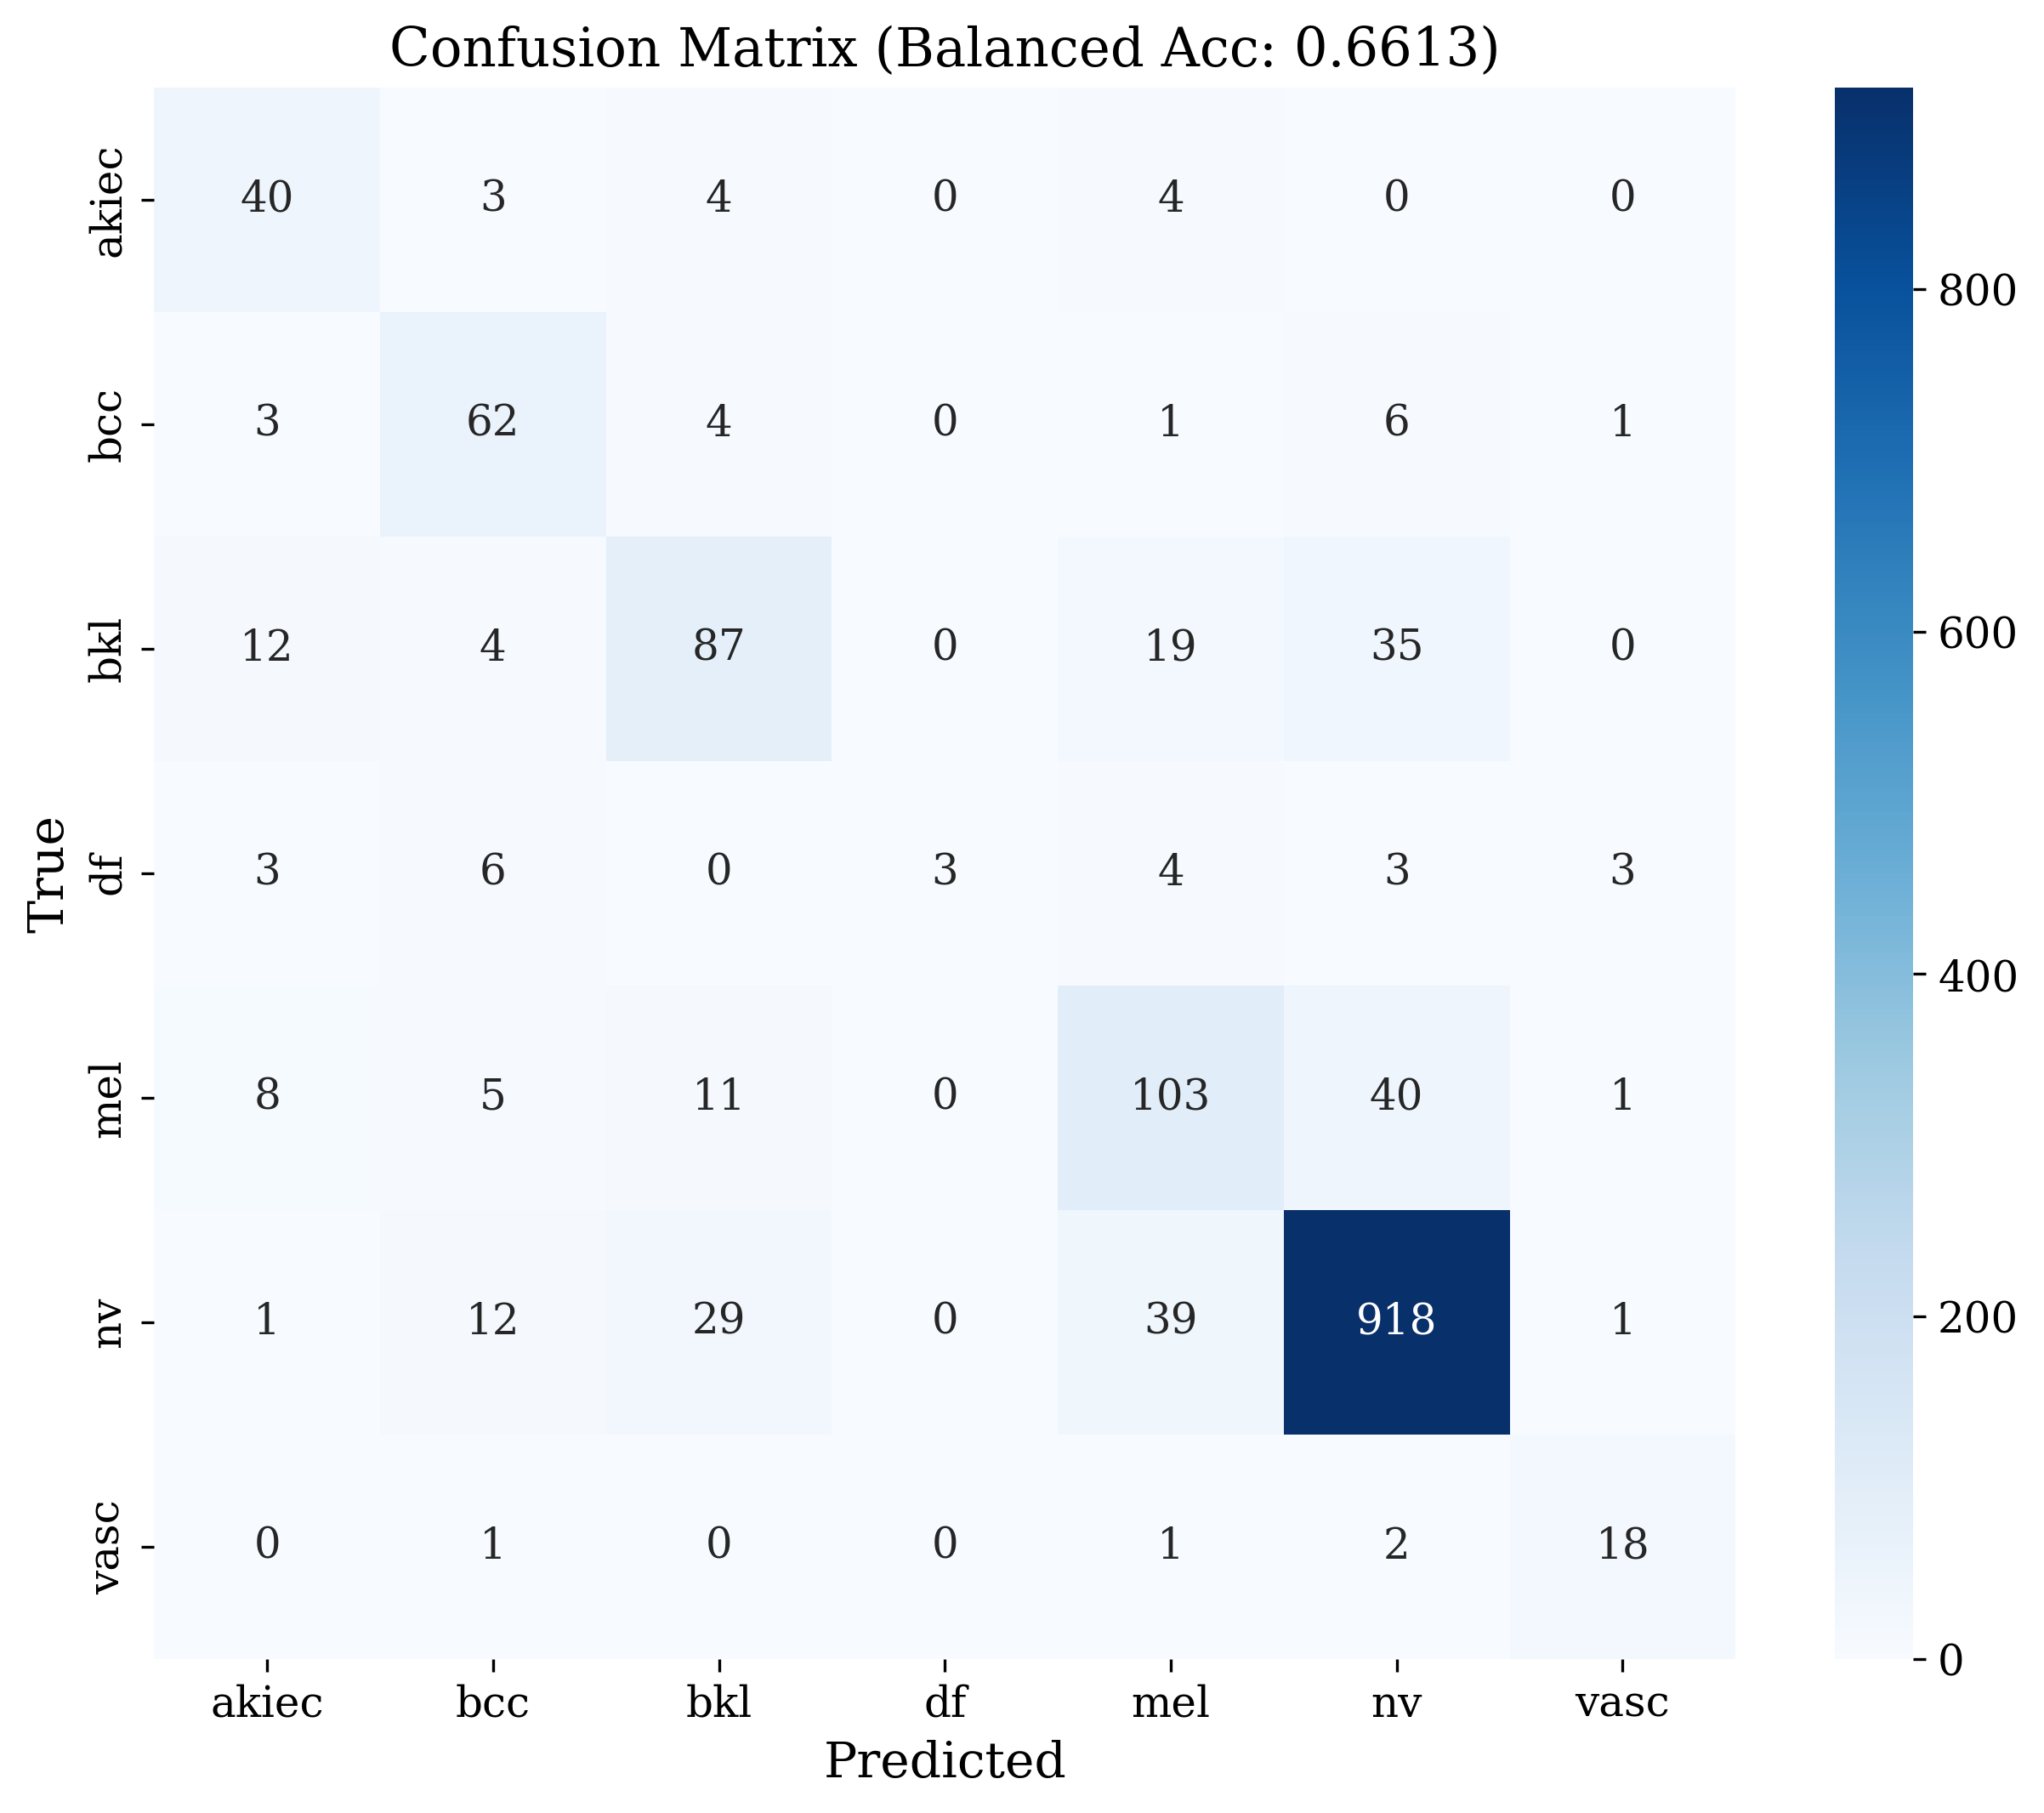

✅ Successfully saved raw data to 'graph_raw_data.csv'
📊 Total points collected: 8469


In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve

def export_graph_data(models, test_loader, mel_idx=4):
    raw_data = []
    
    print("💾 Extracting raw curve data...")
    
    for name, model in models.items():
        # 1. ดึงค่าความน่าจะเป็น
        # ใช้ _ เพื่อข้าม y_pred ตามที่คุณแก้ไขไปล่าสุด
        y_true, _, y_prob = evaluate_model_performance(model, test_loader, device)
        
        y_true = np.array(y_true)
        y_prob = np.array(y_prob)
        
        # เตรียมข้อมูล One-vs-Rest (Melanoma)
        y_true_bin = (y_true == mel_idx).astype(int)
        y_score = y_prob[:, mel_idx]
        
        # --- A. ข้อมูลสำหรับ ROC Curve ---
        fpr, tpr, roc_thresh = roc_curve(y_true_bin, y_score)
        
        # บันทึกลง list (เรียงทีละจุด)
        for i in range(len(fpr)):
            raw_data.append({
                "Model": name,
                "Graph_Type": "ROC",
                "Step": i,
                "X_Value": fpr[i],       # FPR
                "Y_Value": tpr[i],       # TPR
                "Threshold": roc_thresh[i]
            })
            
        # --- B. ข้อมูลสำหรับ PR Curve ---
        precision, recall, pr_thresh = precision_recall_curve(y_true_bin, y_score)
        
        # หมายเหตุ: pr_thresh จะมีขนาดน้อยกว่า precision/recall อยู่ 1 ตัวเสมอ
        # เราจะวนลูปเท่าจำนวน threshold และเก็บค่าสุดท้ายแยก
        for i in range(len(pr_thresh)):
            raw_data.append({
                "Model": name,
                "Graph_Type": "PR",
                "Step": i,
                "X_Value": recall[i],    # Recall
                "Y_Value": precision[i], # Precision
                "Threshold": pr_thresh[i]
            })
        
        # เก็บจุดสุดท้ายของ PR Curve (ที่ Recall=0, Precision=1)
        raw_data.append({
            "Model": name,
            "Graph_Type": "PR",
            "Step": len(pr_thresh),
            "X_Value": recall[-1],
            "Y_Value": precision[-1],
            "Threshold": 1.0 # สมมติว่าเป็น 1.0 สำหรับจุดจบ
        })

    # สร้าง DataFrame และเซฟเป็น CSV
    df = pd.DataFrame(raw_data)
    filename = "graph_raw_data.csv"
    df.to_csv(filename, index=False)
    
    print(f"✅ Successfully saved raw data to '{filename}'")
    print(f"📊 Total points collected: {len(df)}")
    return df

# เรียกใช้งาน
if loaded_models:
    export_graph_data(loaded_models, test_loader, mel_idx=4)

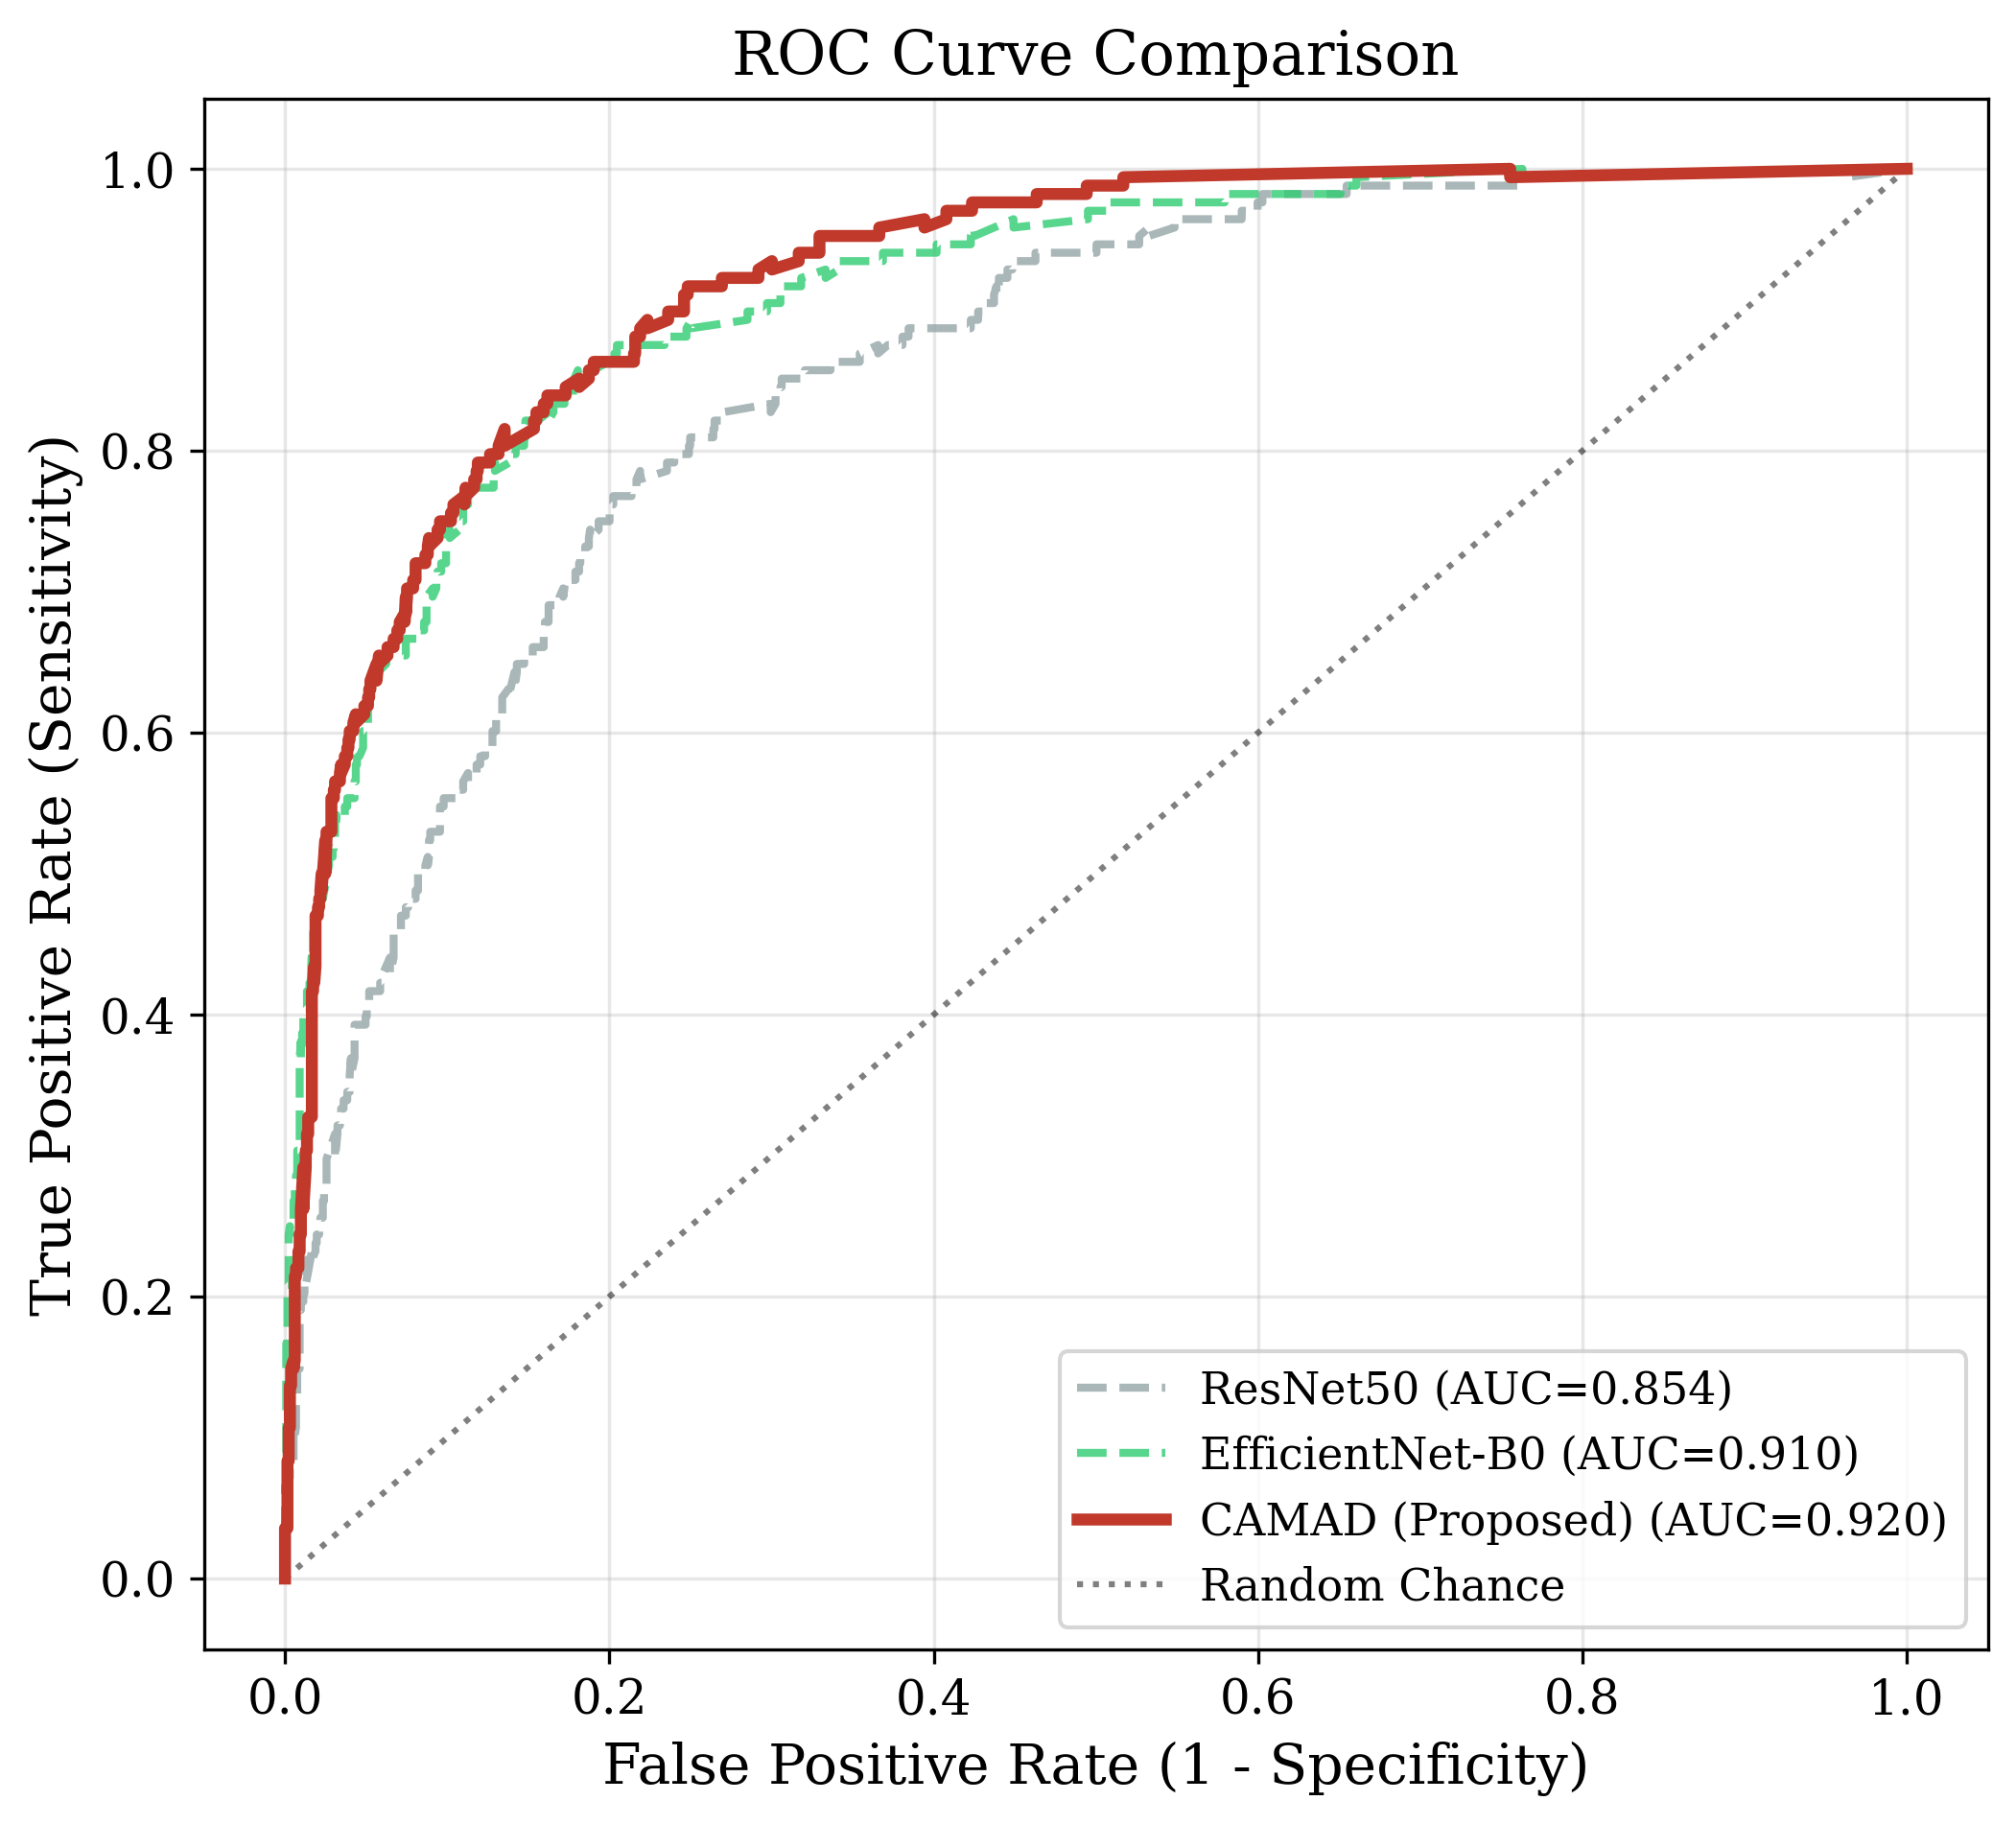

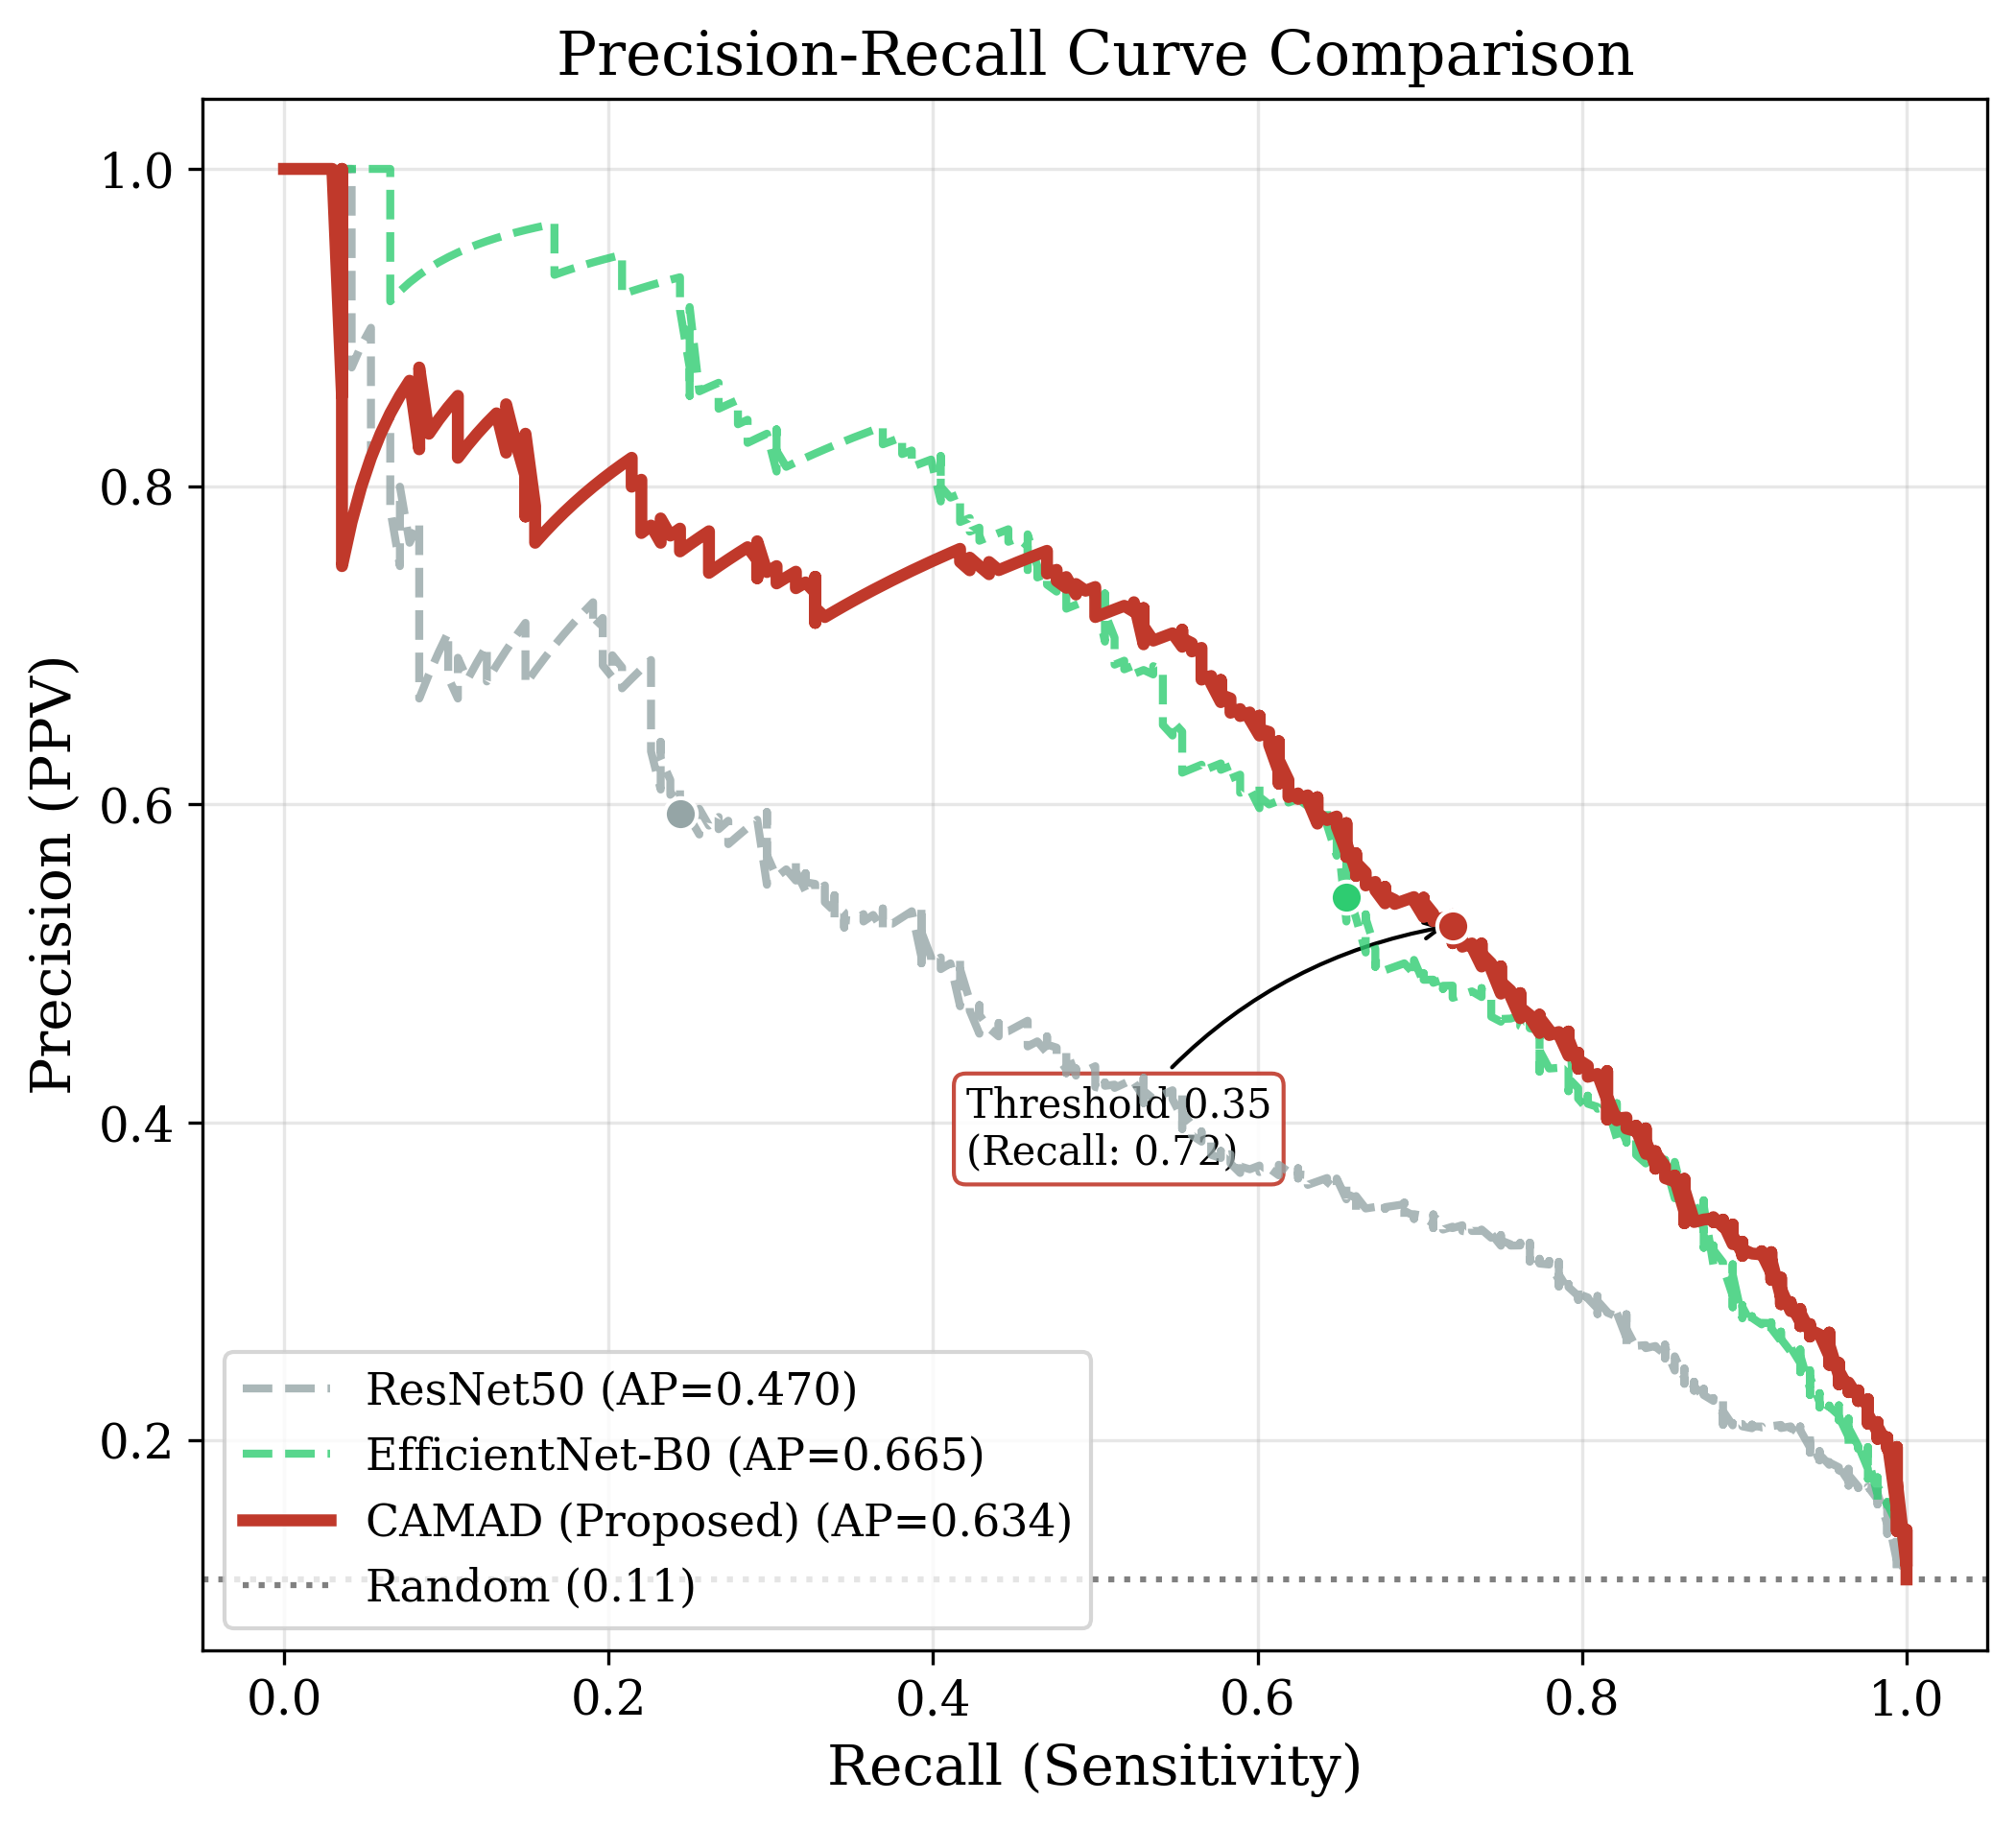

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc

# 1. โหลดข้อมูล
df = pd.read_csv('graph_raw_data.csv')

# 2. เลือกเฉพาะ 3 โมเดลหลัก
colors = {
    "Exp1: Baseline (Vanilla)": "#95a5a6", # สีเทา
    "External: EfficientNet-B0": "#2ecc71", # สีเขียว
    "Exp4: Full CAMAD": "#c0392b"         # สีแดง (Hero)
}

# กำหนดลำดับการวาด
model_order = [
    "Exp1: Baseline (Vanilla)",
    "External: EfficientNet-B0",
    "Exp4: Full CAMAD"
]

# ตั้งค่าสไตล์กราฟ
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 300
})

# สร้าง dictionary สำหรับแมปชื่อ (ใช้ร่วมกันทั้งสองกราฟ)
name_mapping = {
    "Exp1: Baseline (Vanilla)": "ResNet50",
    "External: EfficientNet-B0": "EfficientNet-B0",
    "Exp4: Full CAMAD": "CAMAD (Proposed)"
}

# --- ROC Curve ---
fig_roc, ax_roc = plt.subplots(figsize=(8, 7))

for model_name in model_order:
    subset = df[(df['Model'] == model_name) & (df['Graph_Type'] == 'ROC')]
    if subset.empty: continue
    
    subset = subset.sort_values(by='X_Value')
    fpr = subset['X_Value'].values
    tpr = subset['Y_Value'].values
    roc_auc = auc(fpr, tpr)
    
    is_hero = "Full CAMAD" in model_name
    lw = 3 if is_hero else 2
    linestyle = '-' if is_hero else '--'
    alpha = 1.0 if is_hero else 0.8
    color = colors.get(model_name, 'black')
    zorder = 10 if is_hero else 5

    # ใช้ mapping
    display_name = name_mapping.get(model_name, model_name)
    
    # ใช้ display_name ใน label
    ax_roc.plot(fpr, tpr, color=color, lw=lw, linestyle=linestyle, alpha=alpha, zorder=zorder,
                label=f'{display_name} (AUC={roc_auc:.3f})')

ax_roc.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random Chance')
ax_roc.set_xlabel('False Positive Rate (1 - Specificity)')
ax_roc.set_ylabel('True Positive Rate (Sensitivity)')
ax_roc.set_title('ROC Curve Comparison')
ax_roc.legend(loc="lower right")
ax_roc.grid(True, alpha=0.3)
fig_roc.savefig('ROC_Curve_Simplified.png', bbox_inches='tight')

# --- PR Curve (เพิ่มจุด Marker) ---
fig_pr, ax_pr = plt.subplots(figsize=(8, 7))

for model_name in model_order:
    subset = df[(df['Model'] == model_name) & (df['Graph_Type'] == 'PR')]
    if subset.empty: continue
    
    # เรียงข้อมูลและดึง Threshold มาด้วย
    subset = subset.sort_values(by='X_Value')
    recall = subset['X_Value'].values
    precision = subset['Y_Value'].values
    thresholds = subset['Threshold'].values
    
    pr_auc = auc(recall, precision)
    
    # Hero Logic
    is_hero = "Full CAMAD" in model_name
    lw = 3 if is_hero else 2
    linestyle = '-' if is_hero else '--'
    alpha = 1.0 if is_hero else 0.8
    color = colors.get(model_name, 'black')
    zorder = 10 if is_hero else 5
    
    # ใช้ mapping เดียวกัน
    display_name = name_mapping.get(model_name, model_name)
    
    # วาดเส้นกราฟปกติ
    ax_pr.plot(recall, precision, color=color, lw=lw, linestyle=linestyle, alpha=alpha, zorder=zorder,
               label=f'{display_name} (AP={pr_auc:.3f})')
    
    # --- วาดจุด Marker ที่ Threshold 0.35 ---
    idx_35 = (np.abs(thresholds - 0.35)).argmin()
    r_35 = recall[idx_35]
    p_35 = precision[idx_35]
    
    # วาดจุดวงกลม (Marker)
    ax_pr.plot(r_35, p_35, 'o', color=color, markersize=8, markeredgecolor='white', zorder=zorder+1)
    
    # ใส่คำอธิบาย (Annotation) เฉพาะโมเดลของเรา
    if is_hero:
        ax_pr.annotate(f'Threshold 0.35\n(Recall: {r_35:.2f})', 
                       xy=(r_35, p_35), 
                       xytext=(r_35-0.3, p_35-0.15),
                       arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3,rad=-0.2"),
                       fontsize=10,
                       bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.9))

baseline_val = 168/1497
ax_pr.axhline(baseline_val, color='gray', linestyle=':', label=f'Random ({baseline_val:.2f})')
ax_pr.set_xlabel('Recall (Sensitivity)')
ax_pr.set_ylabel('Precision (PPV)')
ax_pr.set_title('Precision-Recall Curve Comparison')
ax_pr.legend(loc="lower left")
ax_pr.grid(True, alpha=0.3)
fig_pr.savefig('PR_Curve_Simplified.png', bbox_inches='tight')

plt.show()

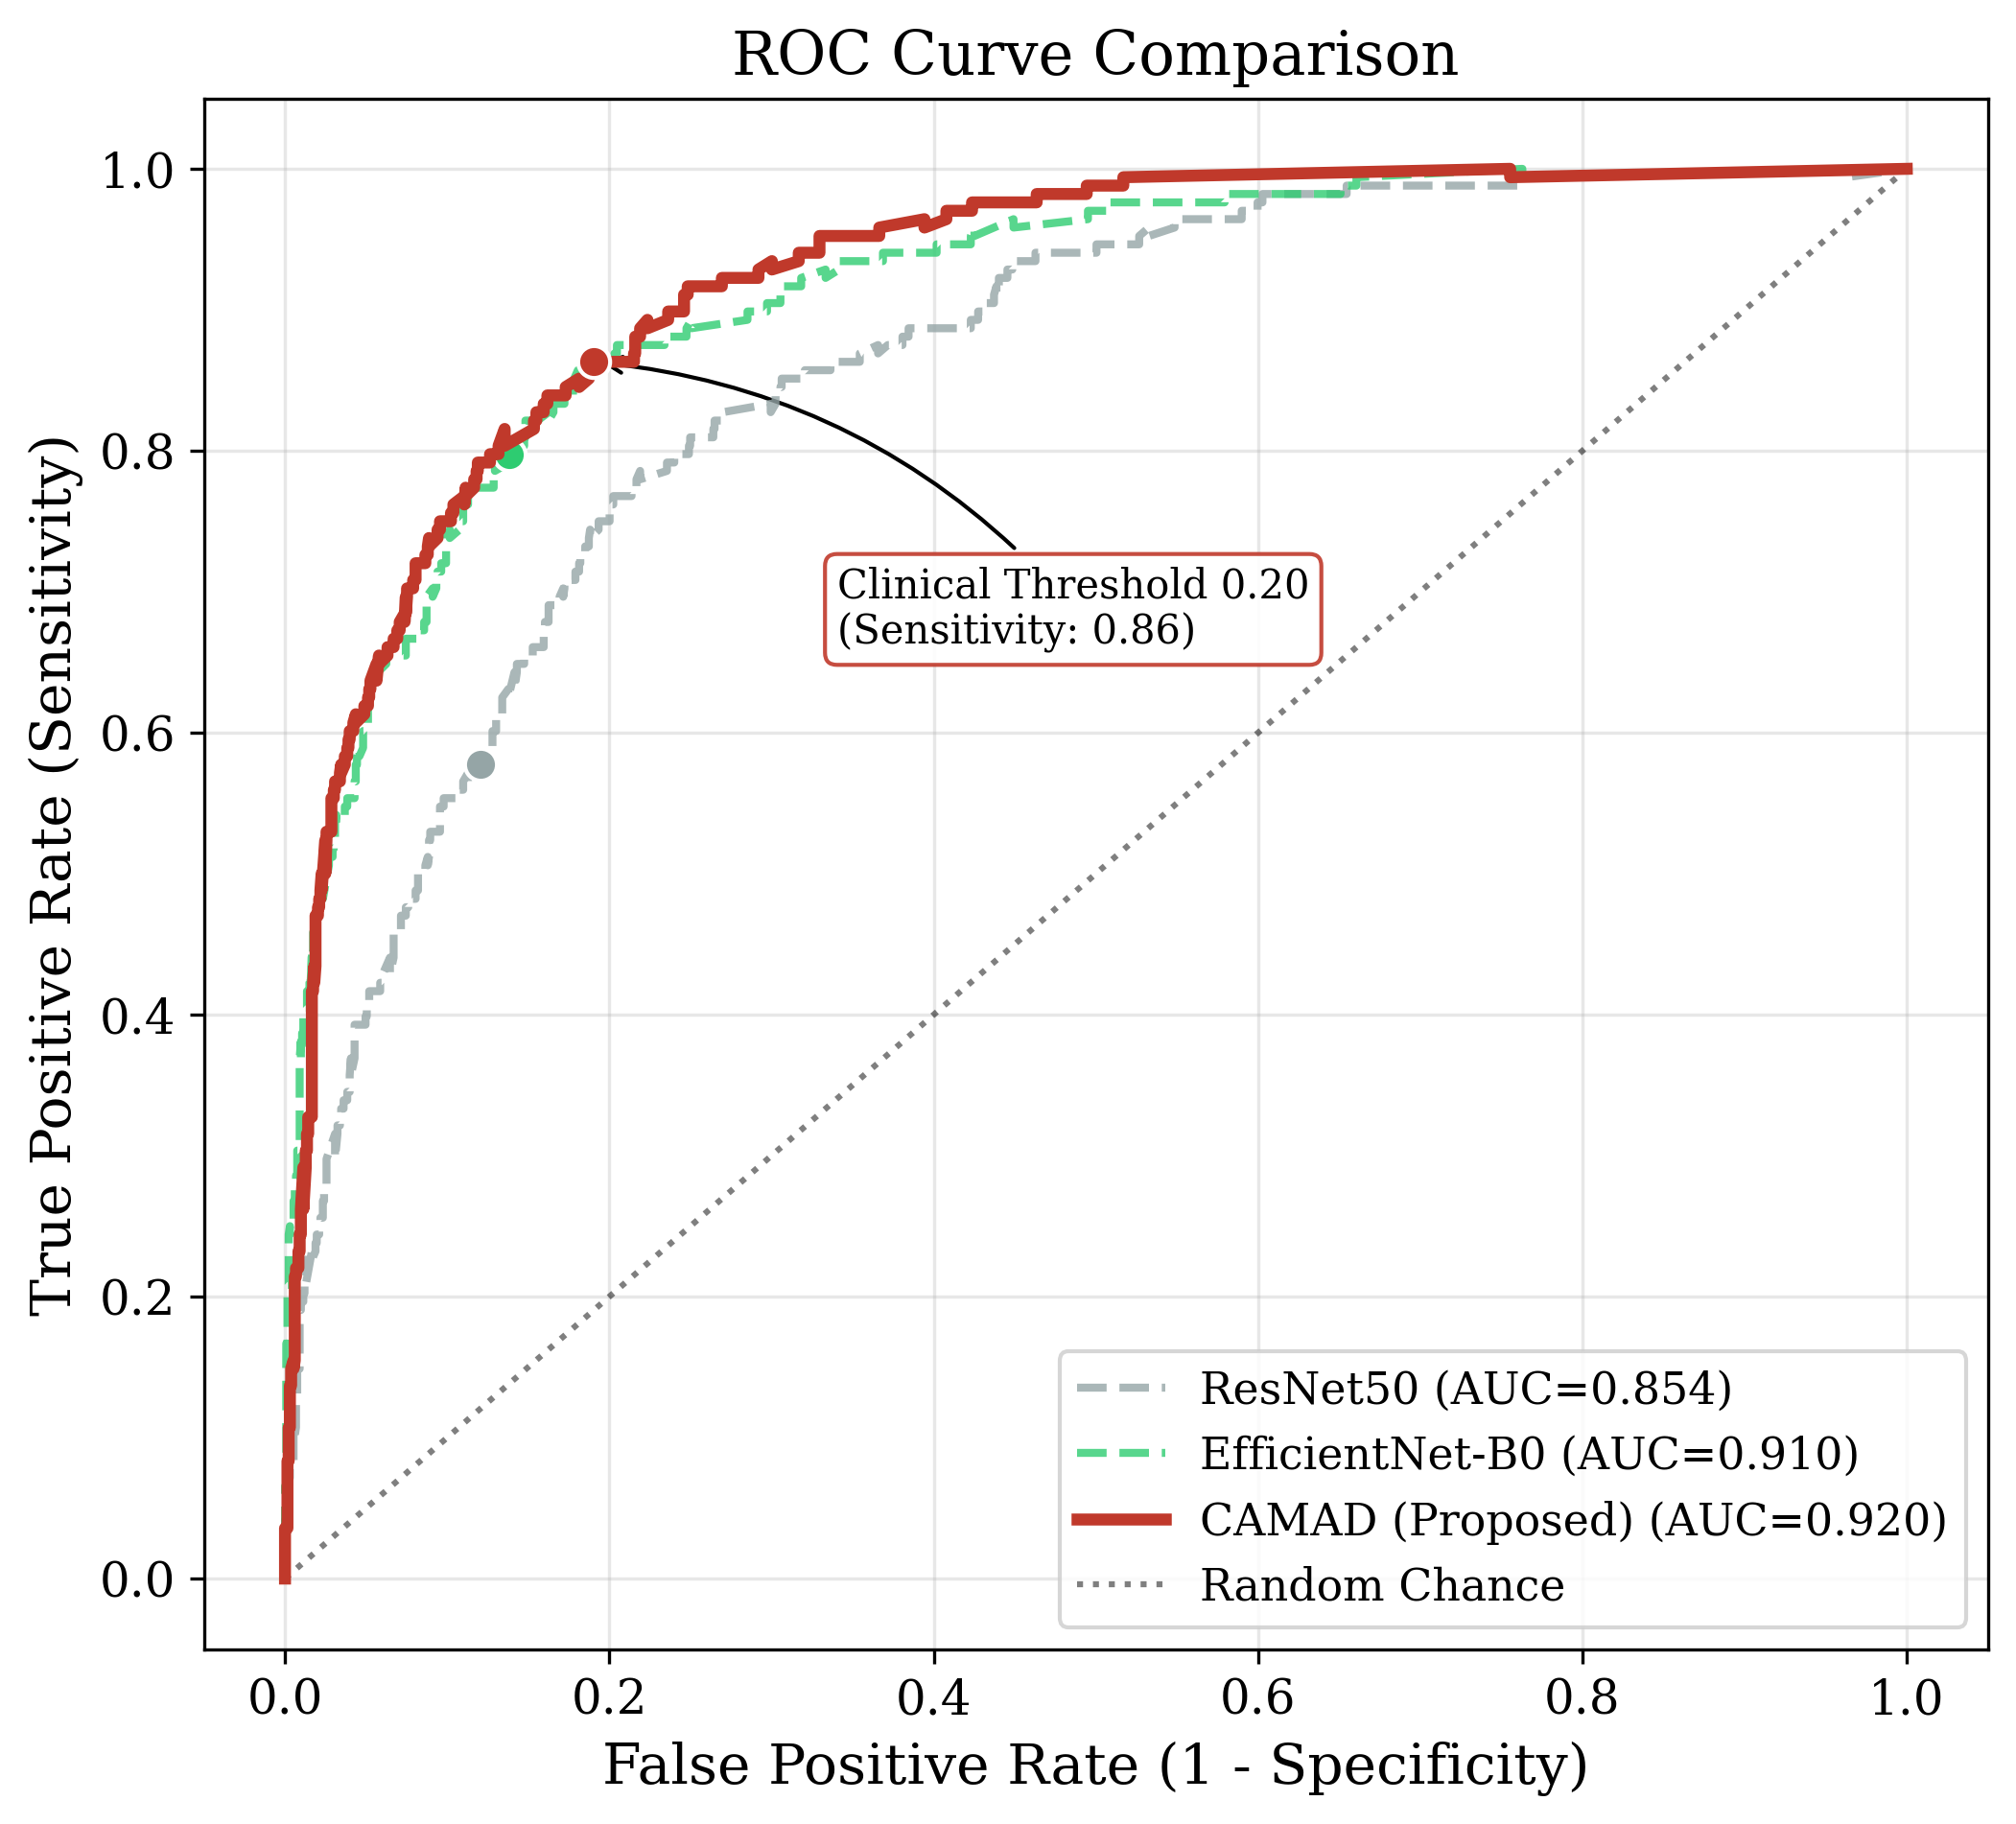

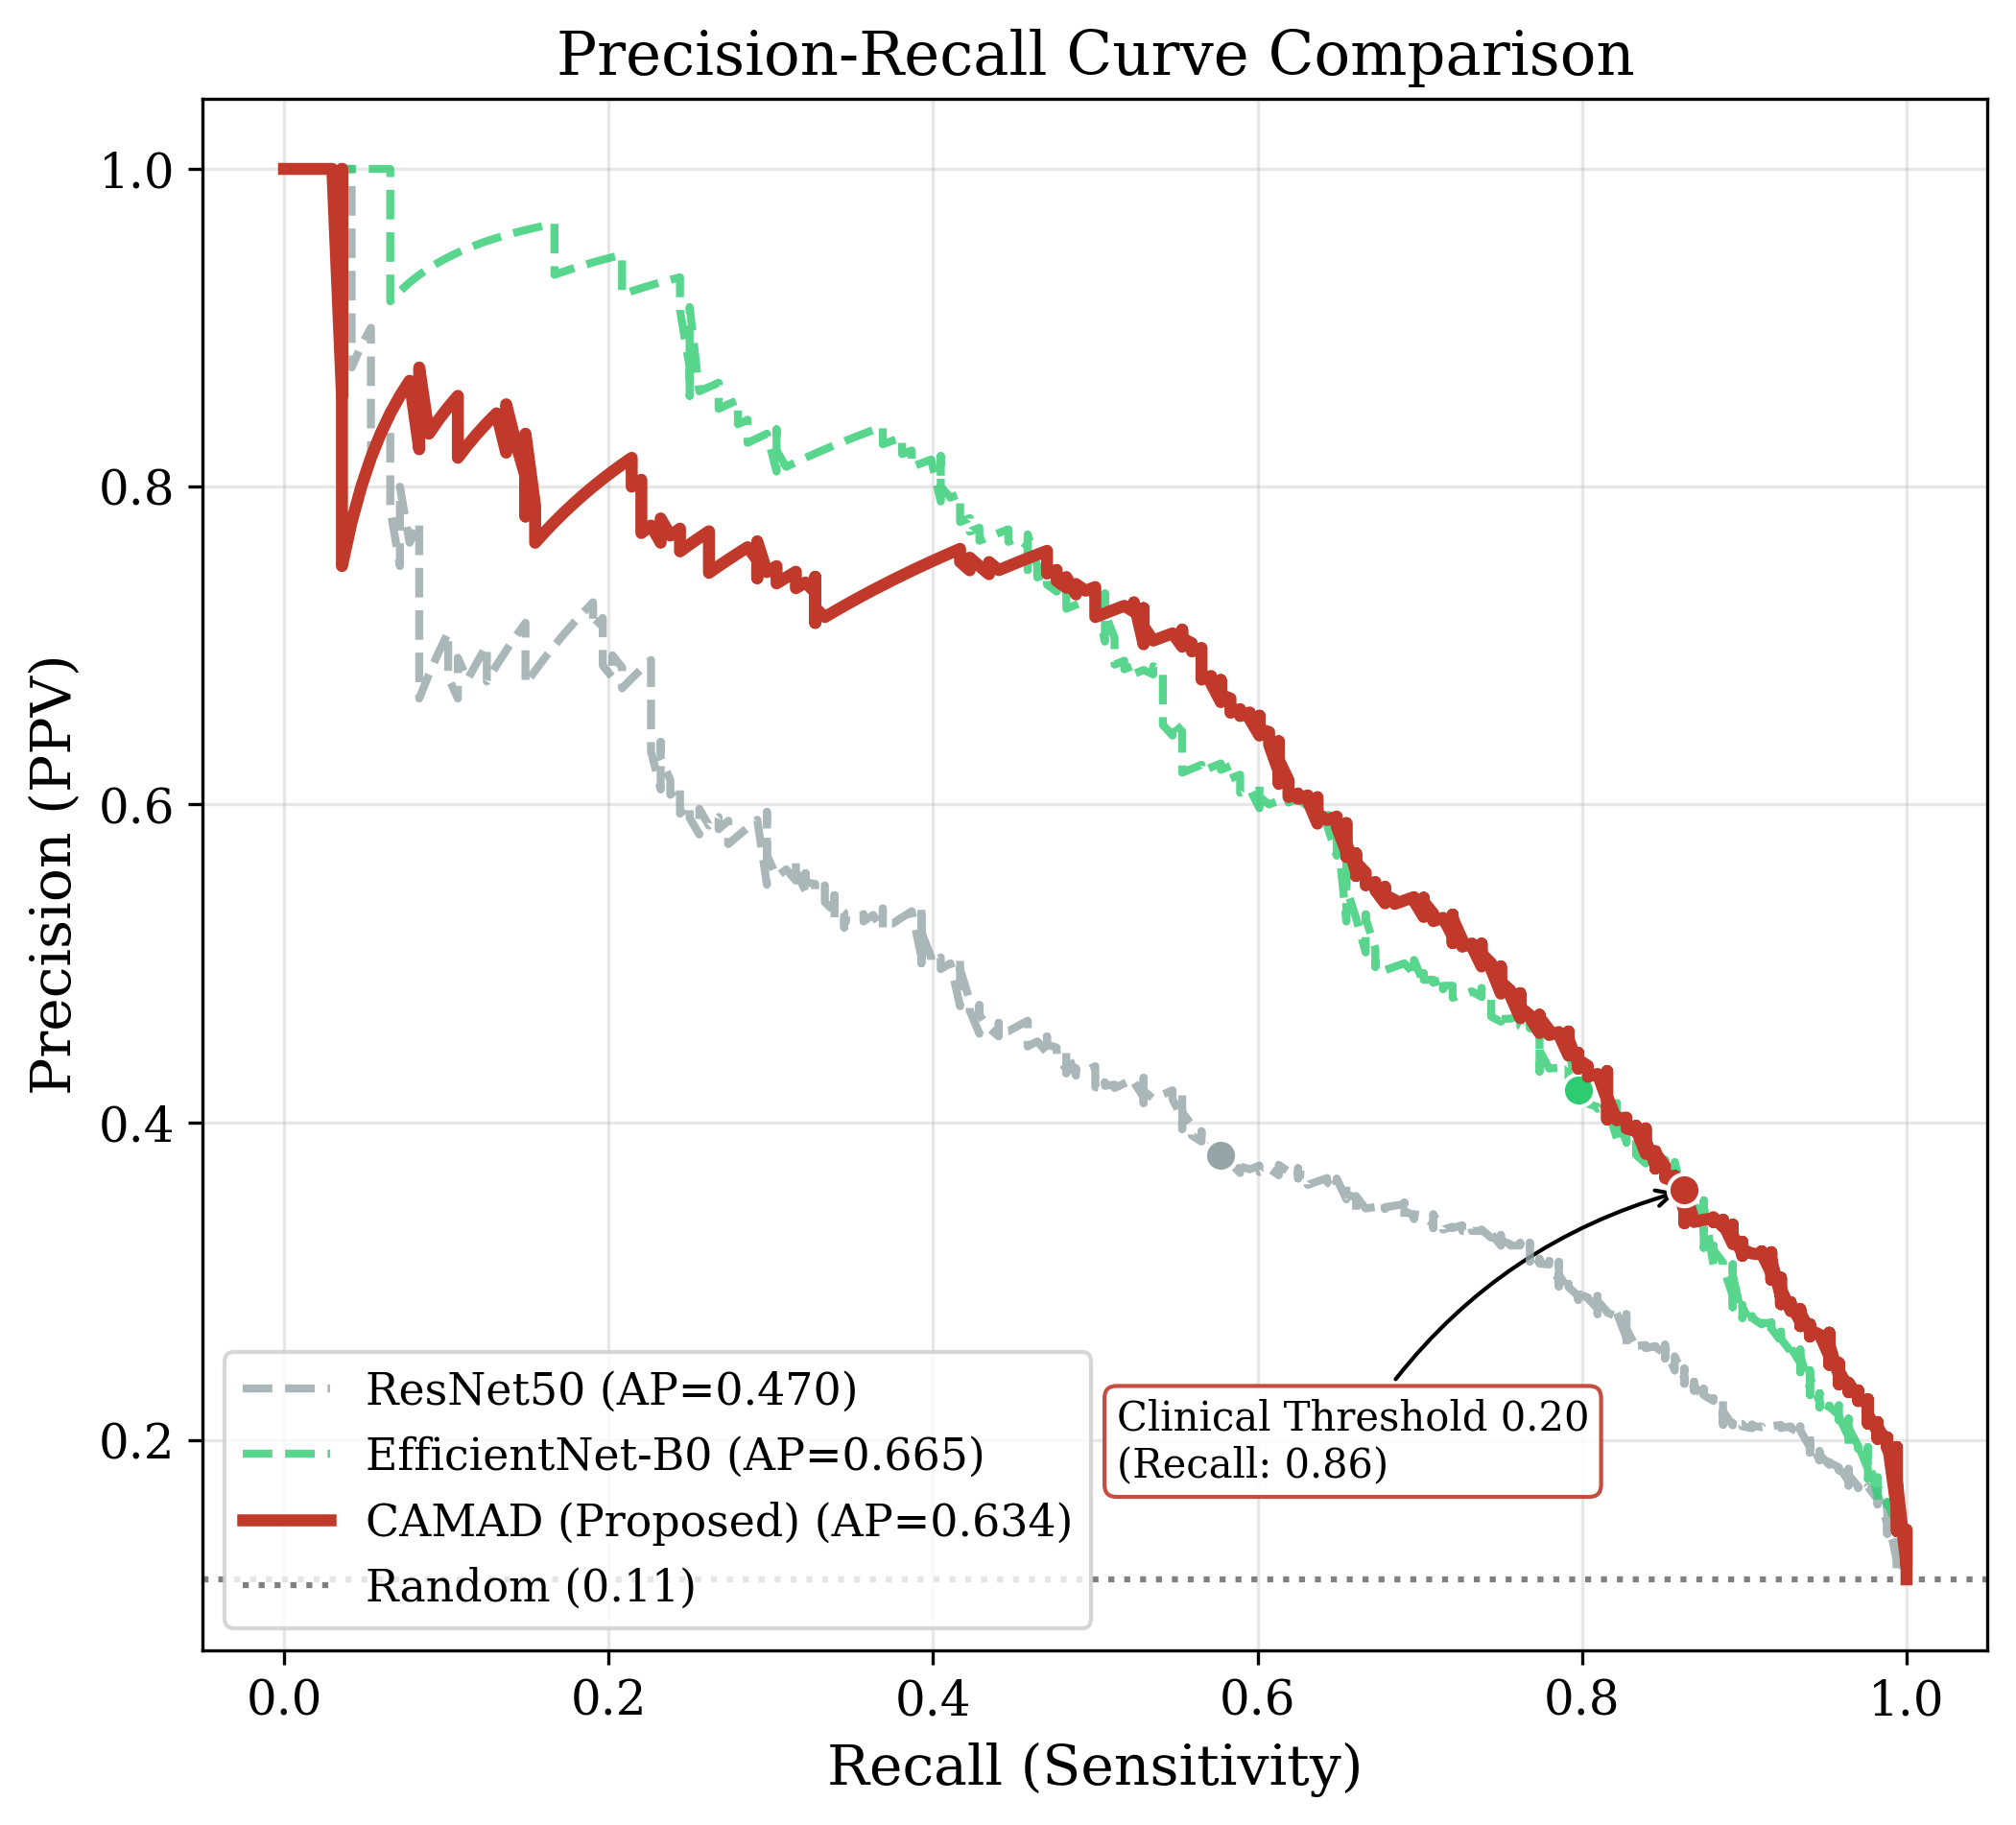

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc

# 1. โหลดข้อมูล
df = pd.read_csv('graph_raw_data.csv')

# 2. เลือกเฉพาะ 3 โมเดลหลัก
colors = {
    "Exp1: Baseline (Vanilla)": "#95a5a6", # สีเทา
    "External: EfficientNet-B0": "#2ecc71", # สีเขียว
    "Exp4: Full CAMAD": "#c0392b"          # สีแดง (Hero)
}

# กำหนดลำดับการวาด
model_order = [
    "Exp1: Baseline (Vanilla)",
    "External: EfficientNet-B0",
    "Exp4: Full CAMAD"
]

# ตั้งค่าสไตล์กราฟ
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 300
})

# สร้าง dictionary สำหรับแมปชื่อ
name_mapping = {
    "Exp1: Baseline (Vanilla)": "ResNet50",
    "External: EfficientNet-B0": "EfficientNet-B0",
    "Exp4: Full CAMAD": "CAMAD (Proposed)"
}

# กำหนดเป้าหมาย Threshold
target_threshold = 0.20

# --- 1. ROC Curve (เพิ่มจุด Marker) ---
fig_roc, ax_roc = plt.subplots(figsize=(8, 7))

for model_name in model_order:
    subset = df[(df['Model'] == model_name) & (df['Graph_Type'] == 'ROC')]
    if subset.empty: continue
    
    subset = subset.sort_values(by='X_Value')
    fpr = subset['X_Value'].values
    tpr = subset['Y_Value'].values
    thresholds = subset['Threshold'].values # ดึงค่า Threshold มาด้วย
    roc_auc = auc(fpr, tpr)
    
    is_hero = "Full CAMAD" in model_name
    lw = 3 if is_hero else 2
    linestyle = '-' if is_hero else '--'
    alpha = 1.0 if is_hero else 0.8
    color = colors.get(model_name, 'black')
    zorder = 10 if is_hero else 5

    display_name = name_mapping.get(model_name, model_name)
    ax_roc.plot(fpr, tpr, color=color, lw=lw, linestyle=linestyle, alpha=alpha, zorder=zorder,
                label=f'{display_name} (AUC={roc_auc:.3f})')
    
    # --- วาดจุด Marker ที่ Threshold 0.20 บน ROC ---
    idx_20 = (np.abs(thresholds - target_threshold)).argmin()
    f_20 = fpr[idx_20]
    t_20 = tpr[idx_20]
    
    # วาดจุดวงกลม
    ax_roc.plot(f_20, t_20, 'o', color=color, markersize=8, markeredgecolor='white', zorder=zorder+1)
    
    # ใส่คำอธิบาย เฉพาะโมเดลนำเสนอ (CAMAD)
    if is_hero:
        ax_roc.annotate(f'Clinical Threshold {target_threshold:.2f}\n(Sensitivity: {t_20:.2f})', 
                       xy=(f_20, t_20), 
                       xytext=(f_20+0.15, t_20-0.2),
                       arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3,rad=0.2"),
                       fontsize=10,
                       bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.9))

ax_roc.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random Chance')
ax_roc.set_xlabel('False Positive Rate (1 - Specificity)')
ax_roc.set_ylabel('True Positive Rate (Sensitivity)')
ax_roc.set_title('ROC Curve Comparison')
ax_roc.legend(loc="lower right")
ax_roc.grid(True, alpha=0.3)
fig_roc.savefig('ROC_Curve_Simplified.png', bbox_inches='tight')

# --- 2. PR Curve (คงเดิมแต่ตรวจสอบความสอดคล้อง) ---
fig_pr, ax_pr = plt.subplots(figsize=(8, 7))

for model_name in model_order:
    subset = df[(df['Model'] == model_name) & (df['Graph_Type'] == 'PR')]
    if subset.empty: continue
    
    subset = subset.sort_values(by='X_Value')
    recall = subset['X_Value'].values
    precision = subset['Y_Value'].values
    thresholds = subset['Threshold'].values
    pr_auc = auc(recall, precision)
    
    is_hero = "Full CAMAD" in model_name
    lw = 3 if is_hero else 2
    linestyle = '-' if is_hero else '--'
    alpha = 1.0 if is_hero else 0.8
    color = colors.get(model_name, 'black')
    zorder = 10 if is_hero else 5
    
    display_name = name_mapping.get(model_name, model_name)
    ax_pr.plot(recall, precision, color=color, lw=lw, linestyle=linestyle, alpha=alpha, zorder=zorder,
               label=f'{display_name} (AP={pr_auc:.3f})')
    
    # --- วาดจุด Marker ที่ Threshold 0.20 บน PR ---
    idx_20 = (np.abs(thresholds - target_threshold)).argmin()
    r_20 = recall[idx_20]
    p_20 = precision[idx_20]
    
    ax_pr.plot(r_20, p_20, 'o', color=color, markersize=8, markeredgecolor='white', zorder=zorder+1)
    
    if is_hero:
        ax_pr.annotate(f'Clinical Threshold {target_threshold:.2f}\n(Recall: {r_20:.2f})', 
                       xy=(r_20, p_20), 
                       xytext=(r_20-0.35, p_20-0.18),
                       arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3,rad=-0.2"),
                       fontsize=10,
                       bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.9))

baseline_val = 168/1497
ax_pr.axhline(baseline_val, color='gray', linestyle=':', label=f'Random ({baseline_val:.2f})')
ax_pr.set_xlabel('Recall (Sensitivity)')
ax_pr.set_ylabel('Precision (PPV)')
ax_pr.set_title('Precision-Recall Curve Comparison')
ax_pr.legend(loc="lower left")
ax_pr.grid(True, alpha=0.3)
fig_pr.savefig('PR_Curve_Simplified.png', bbox_inches='tight')

plt.show()